# Exploratory Data Analysis & Statistical Analysis
**Trump Posts vs S&P 500 — NLP Final Assignment**

### Structure
1. Imports, paths & colour palette
2. Data loading
3. Post volume over time
4. Engagement statistics
5. Content analysis — BERTopic themes & word frequency
6. Sentiment distributions
7. Platform comparison: Twitter vs Truth Social
8. Sentiment vs S&P 500
9. Correlation structure
10. Novelty score & embedding diversity
11. Key event spotlights
12. Lagged cross-correlation analysis
13. Significance testing (Newey-West HAC)
14. Topic-level regression
15. Event study (CAR around extreme posts)
16. Platform subgroup analysis
17. Save results


---
## 1 — Imports, Paths & Colour Palette

All colours are defined once here and reused throughout every plot.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac

# ── Seaborn base style ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 150,
})

# ── Consistent colour palette (used everywhere) ───────────────────────────────
# Sentiment colours — never reused for anything else
C_POSITIVE  = "#2ecc71"   # green
C_NEUTRAL   = "#95a5a6"   # grey
C_NEGATIVE  = "#e74c3c"   # red

# Platform colours
C_TWITTER   = "#1DA1F2"   # Twitter blue
C_TRUTH     = "#FF6B35"   # Truth Social orange

# Market colours
C_MARKET_UP   = "#27ae60"  # dark green
C_MARKET_DOWN = "#c0392b"  # dark red
C_SP500       = "#2c3e50"  # dark navy

# General accent
C_ACCENT    = "#3498db"   # blue  (bars, lines, scatter)
C_ACCENT2   = "#9b59b6"   # purple (secondary)
C_HIGHLIGHT = "#f39c12"   # orange (significance stars, highlights)

SENTIMENT_PALETTE = {
    "positive": C_POSITIVE,
    "neutral":  C_NEUTRAL,
    "negative": C_NEGATIVE,
}

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
print("Imports OK")
print("Colour palette defined.")


Imports OK
Colour palette defined.


---
## 2 — Paths & Data Loading

In [2]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "3_feature_engineering" / "features").exists():
            return p
    raise FileNotFoundError("Project root not found.")

PROJECT_ROOT = find_project_root()
FEATURE_DIR  = PROJECT_ROOT / "3_feature_engineering" / "features"
OUTPUT_DIR   = PROJECT_ROOT / "4_eda" / "figures"
ANALYSIS_DIR = PROJECT_ROOT / "5_analysis" / "results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.savefig(OUTPUT_DIR / f"{name}.png")
    print(f"  Saved: {name}.png")

print("Project root:", PROJECT_ROOT)


Project root: c:\Dev\nlp-final-project


In [3]:
tweets = pd.read_pickle(FEATURE_DIR / "tweets_features.pkl")
tweets["date_only"] = pd.to_datetime(tweets["date_only"]).dt.tz_localize(None)
tweets["year"]  = tweets["date_only"].dt.year
tweets["month"] = tweets["date_only"].dt.to_period("M").dt.to_timestamp()

fm = pd.read_csv(FEATURE_DIR / "feature_matrix.csv", parse_dates=["date_only"])
fm["date_only"] = pd.to_datetime(fm["date_only"]).dt.tz_localize(None)
fm["year"] = fm["date_only"].dt.year

print(f"Tweets       : {len(tweets):,} rows")
print(f"Feature matrix: {len(fm):,} trading days")
print(f"Date range   : {tweets['date_only'].min().date()} → {tweets['date_only'].max().date()}")


Tweets       : 74,742 rows
Feature matrix: 3,526 trading days
Date range   : 2009-05-04 → 2026-01-08


---
## 3 — Post Volume Over Time

How many posts did Trump publish per year, and how did that split between platforms?
Pre-market posts (04:00–09:29 ET) are flagged separately as they could precede market open.


Pre-market posts (04:00–09:29 ET): 12,012 (16.1%)
  Saved: 01_post_volume.png


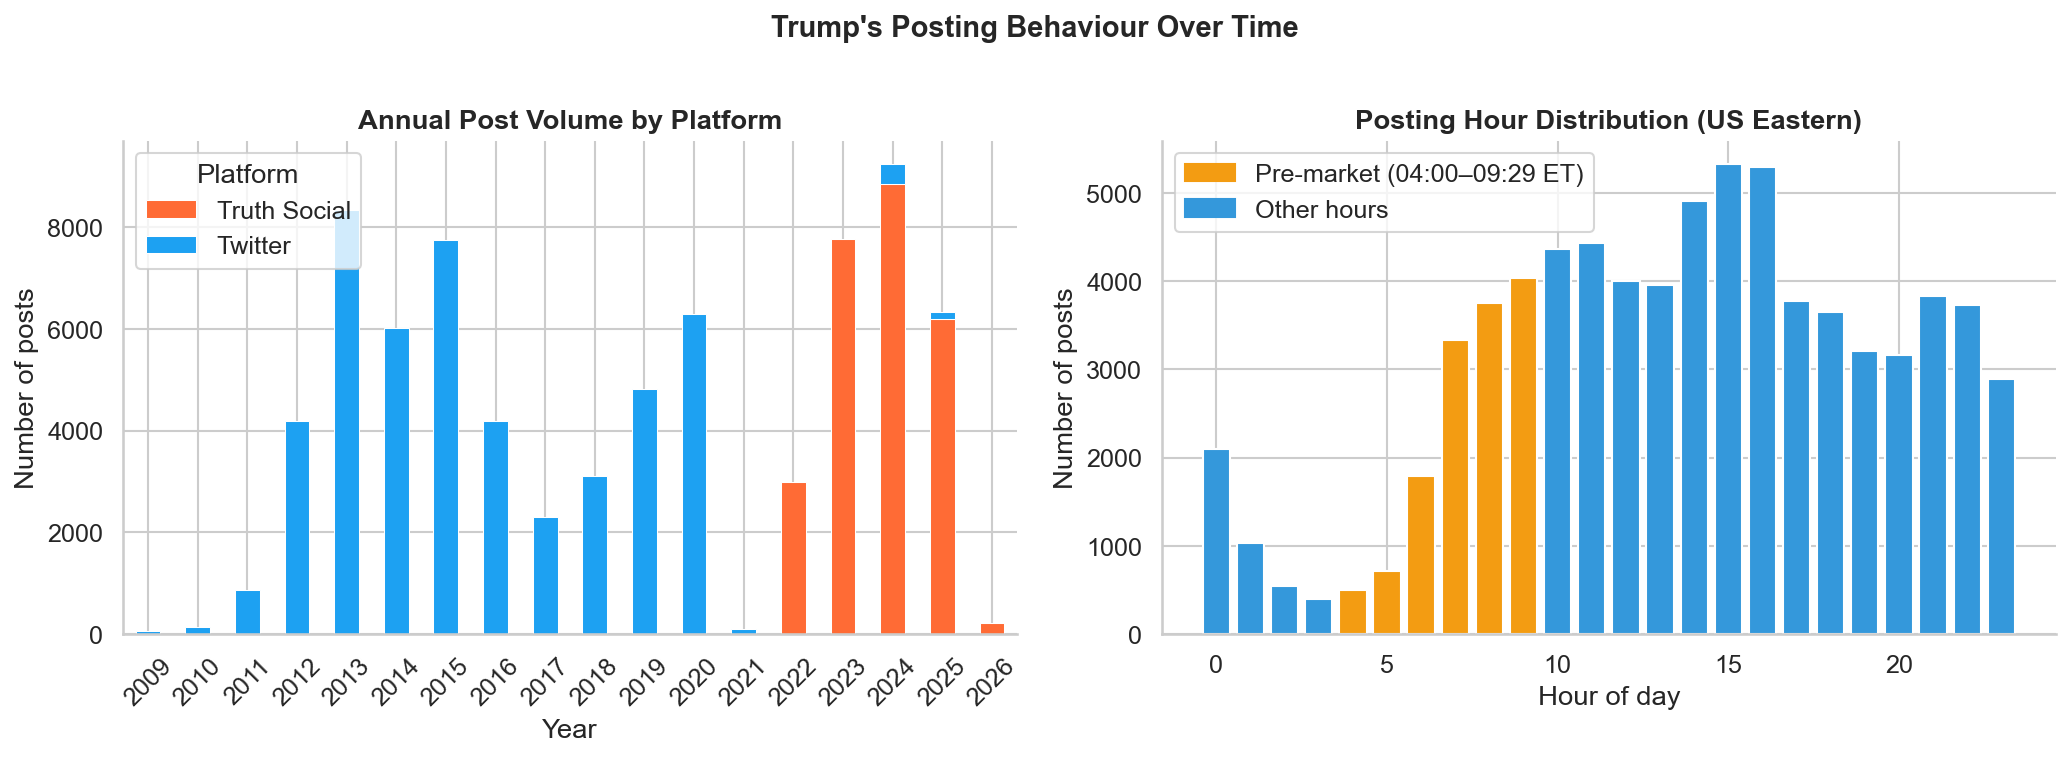

In [9]:
# ── Annual post count + corrected pre-market hour distribution ───────────────
annual = tweets.groupby(["year", "platform"]).size().reset_index(name="count")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: stacked bar by platform
pivot = annual.pivot(
    index="year", columns="platform", values="count"
).fillna(0)
pivot.plot(
    kind="bar", ax=axes[0], stacked=True,
    color=[C_TRUTH, C_TWITTER], edgecolor="white", linewidth=0.5
)
axes[0].set_title("Annual Post Volume by Platform", fontweight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of posts")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Platform")

# Right: posting hour distribution with precise pre-market window
# Pre-market = 04:00:00 to 09:29:59 ET using actual timestamps
dt = pd.to_datetime(tweets["date_et"], utc=True).dt.tz_convert("America/New_York")

pre_market_mask = (
    (dt.dt.hour > 4) |
    (dt.dt.hour == 4)
) & (
    (dt.dt.hour < 9) |
    ((dt.dt.hour == 9) & (dt.dt.minute < 30))
)

# Precise pre-market count for the print statement
n_pre = pre_market_mask.sum()
pct   = 100 * n_pre / len(tweets)
print(f"Pre-market posts (04:00–09:29 ET): {n_pre:,} ({pct:.1f}%)")

# Build hour-level bar colours using the precise mask
tweets["_pre_market"] = pre_market_mask
tweets["_hour"]       = dt.dt.hour

hour_counts  = tweets["_hour"].value_counts().sort_index()
pre_by_hour  = tweets[tweets["_pre_market"]]["_hour"].value_counts()

colors_hour = [
    C_HIGHLIGHT if h in pre_by_hour.index else C_ACCENT
    for h in hour_counts.index
]

axes[1].bar(
    hour_counts.index, hour_counts.values,
    color=colors_hour, edgecolor="white"
)
axes[1].set_title("Posting Hour Distribution (US Eastern)", fontweight="bold")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Number of posts")

pre_patch   = mpatches.Patch(color=C_HIGHLIGHT, label="Pre-market (04:00–09:29 ET)")
other_patch = mpatches.Patch(color=C_ACCENT,    label="Other hours")
axes[1].legend(handles=[pre_patch, other_patch])

# Clean up temp columns
tweets.drop(columns=["_pre_market", "_hour"], inplace=True)

plt.suptitle(
    "Trump's Posting Behaviour Over Time",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
savefig("01_post_volume")
plt.show()

In [8]:
tweets["date_et"]

0       2009-05-04 14:54:25-04:00
1       2009-05-04 21:00:10-04:00
2       2009-05-08 09:38:08-04:00
3       2009-05-08 16:40:15-04:00
4       2009-05-12 10:07:28-04:00
                   ...           
74737   2026-01-07 16:17:38-05:00
74738   2026-01-07 17:04:26-05:00
74739   2026-01-07 18:53:08-05:00
74740   2026-01-07 23:05:33-05:00
74741   2026-01-08 07:42:42-05:00
Name: date_et, Length: 74742, dtype: datetime64[ns, US/Eastern]

---
## 4 — Engagement Statistics

Engagement is strongly right-skewed — a small number of posts attract most of the attention.
We use log-transformed engagement to visualise the distribution cleanly.


  Saved: 02_engagement.png


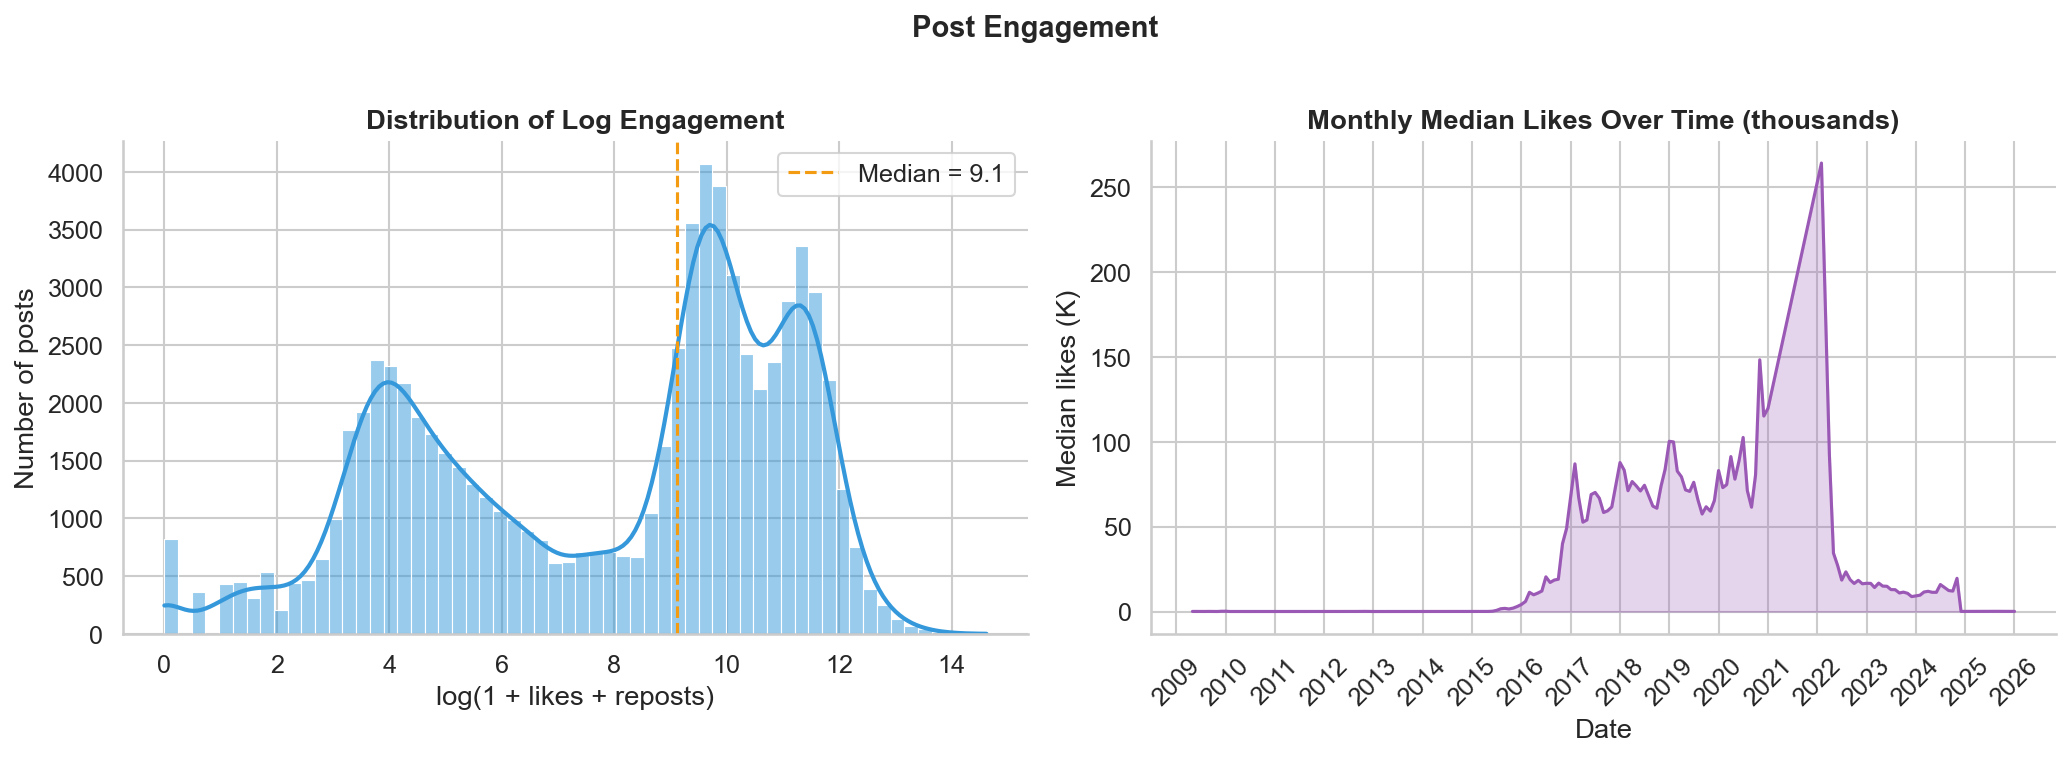


Engagement summary:
       favorite_count  repost_count  log_engagement
count      74742.0000    74742.0000      74742.0000
mean       26191.8700     5976.1200          7.8100
std        52475.3300    10687.8500          3.2400
min            0.0000        0.0000          0.0000
25%           57.0000       40.0000          4.7000
50%         7081.0000     1907.0000          9.1100
75%        28185.7500     7399.7500         10.4900
max      1905628.0000   398663.0000         14.6200


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: log engagement distribution
if "log_engagement" in tweets.columns:
    sns.histplot(tweets["log_engagement"].dropna(), bins=60,
                 color=C_ACCENT, ax=axes[0], kde=True,
                 line_kws={"linewidth": 2})
    axes[0].set_title("Distribution of Log Engagement", fontweight="bold")
    axes[0].set_xlabel("log(1 + likes + reposts)")
    axes[0].set_ylabel("Number of posts")
    med = tweets["log_engagement"].median()
    axes[0].axvline(med, color=C_HIGHLIGHT, linestyle="--", linewidth=1.5,
                    label=f"Median = {med:.1f}")
    axes[0].legend()

# Right: median monthly likes over time
if "favorite_count" in tweets.columns:
    monthly_eng = tweets.groupby("month")["favorite_count"].median().reset_index()
    axes[1].fill_between(monthly_eng["month"], monthly_eng["favorite_count"] / 1e3,
                         alpha=0.25, color=C_ACCENT2)
    axes[1].plot(monthly_eng["month"], monthly_eng["favorite_count"] / 1e3,
                 color=C_ACCENT2, linewidth=1.5)
    axes[1].set_title("Monthly Median Likes Over Time (thousands)", fontweight="bold")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Median likes (K)")
    axes[1].xaxis.set_major_locator(mdates.YearLocator())
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(axes[1].get_xticklabels(), rotation=45)

plt.suptitle("Post Engagement", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
savefig("02_engagement")
plt.show()

print("\nEngagement summary:")
print(tweets[["favorite_count", "repost_count", "log_engagement"]].describe().round(2))


---
## 5 — Content Analysis: BERTopic Themes & Word Frequency

We show the distribution of BERTopic-discovered themes and the most frequent
lemmas across the corpus.


  Saved: 03_content_analysis.png


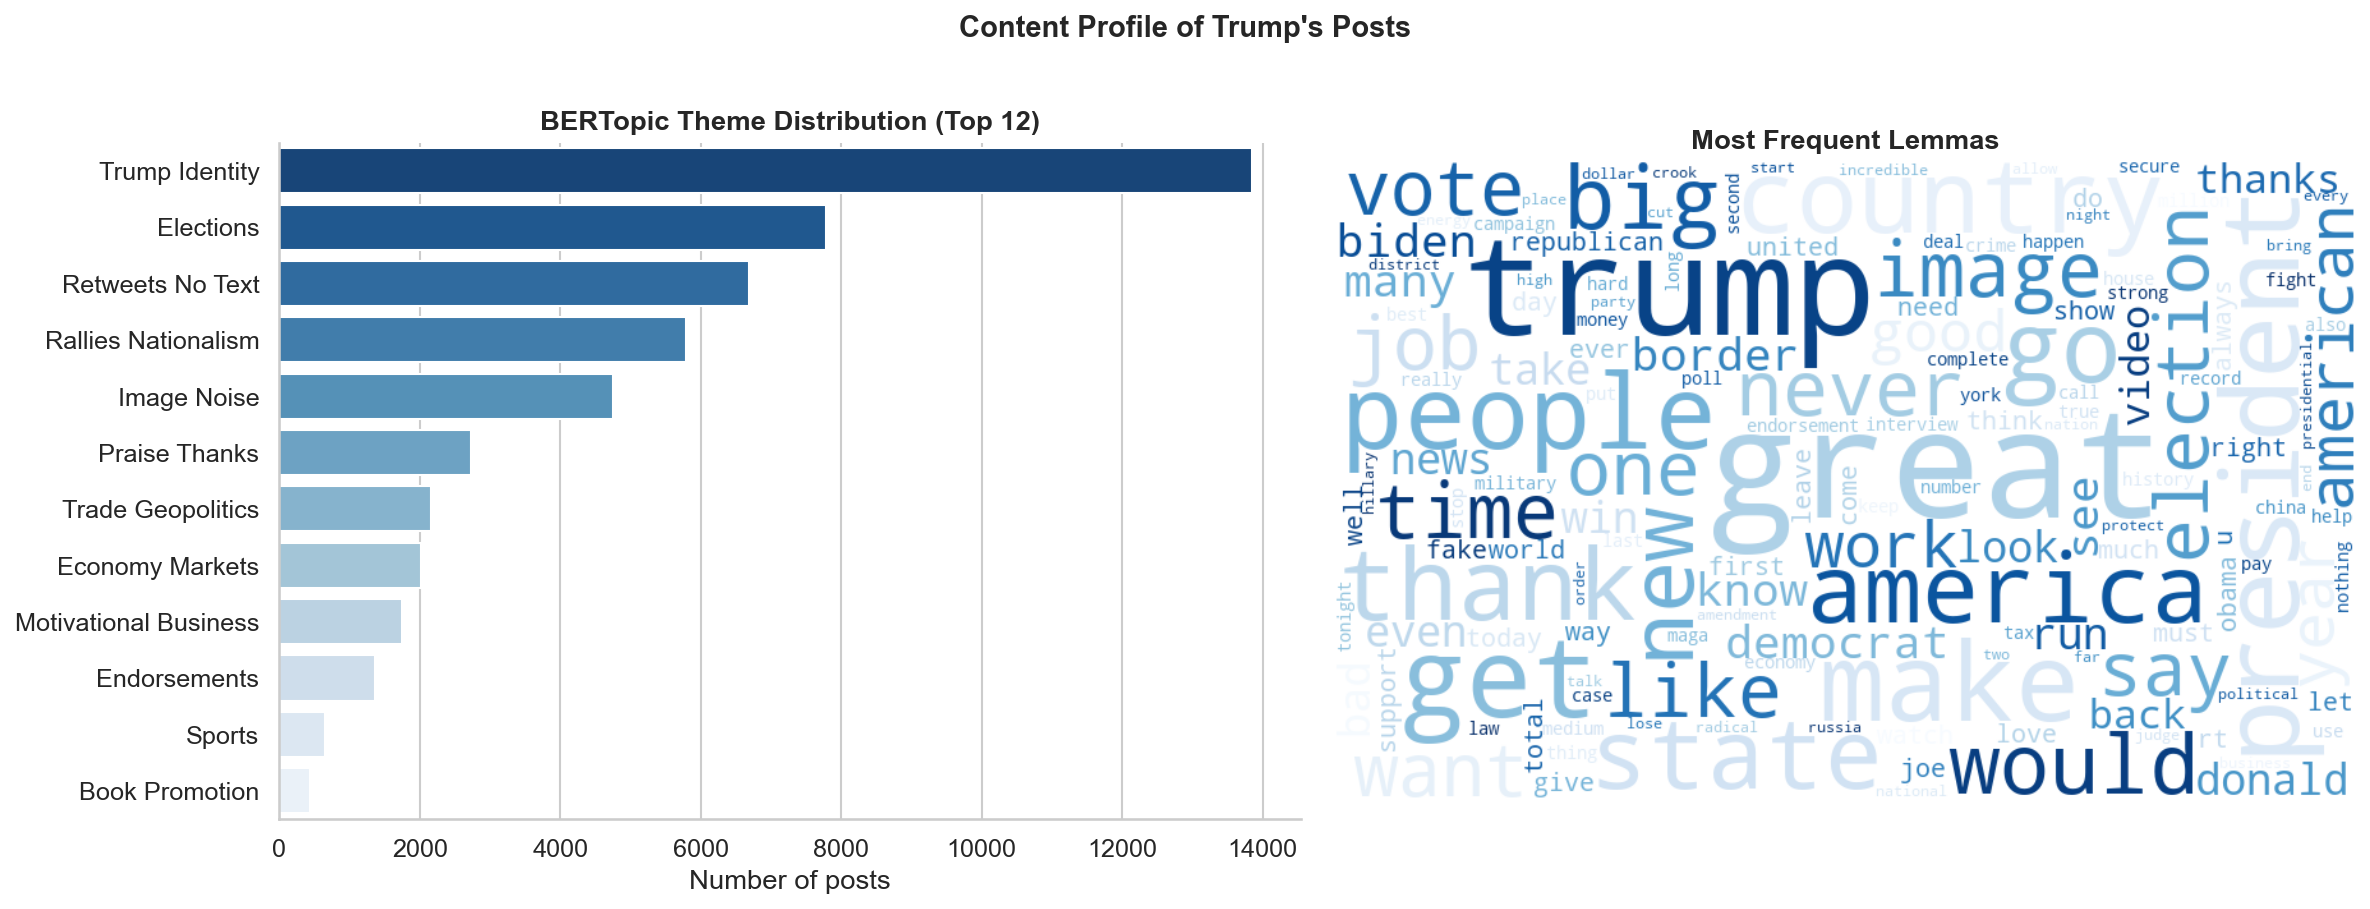

In [19]:

import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: BERTopic topic distribution 

# Map topic IDs to friendly names using BERTOPIC_THEME_MAP
# (defined in the feature engineering notebook)
BERTOPIC_THEME_MAP = {
    0:  "topic_trump_identity",
    1:  "topic_elections",
    2:  "retweets_no_text",
    3:  "topic_rallies_nationalism",
    4:  "image_noise",
    5:  "topic_praise_thanks",
    6:  "topic_trade_geopolitics",
    7:  "topic_economy_markets",
    8:  "topic_motivational_business",
    9:  "topic_endorsements",
    10: "topic_sports",
    11: "topic_book_promotion",
    12: "topic_energy_environment",
    13: "topic_mitt_dinner"
}

# Reverse map: "topic_0" → friendly label
id_to_name = {
    f"topic_{k}": v.replace("topic_", "").replace("_", " ").title()
    for k, v in BERTOPIC_THEME_MAP.items()
}
# Anything not in the map gets a generic label

def friendly_label(raw):
    return id_to_name.get(raw, raw.replace("topic_", "Topic ").replace("_", " ").title())

topic_col = "bertopic_label" if "bertopic_label" in tweets.columns else "cluster_label"
topic_counts = (
    tweets[tweets[topic_col] != "outlier"][topic_col]
    .value_counts()
    .head(12)
    .reset_index()
)
topic_counts.columns = ["topic", "count"]
topic_counts["topic"] = topic_counts["topic"].apply(friendly_label)

sns.barplot(data=topic_counts, y="topic", x="count",
            palette="Blues_r", ax=axes[0])
axes[0].set_title("BERTopic Theme Distribution (Top 12)", fontweight="bold")
axes[0].set_xlabel("Number of posts")
axes[0].set_ylabel("")

# Right: word cloud on lemmatized text
if "lemmas" in tweets.columns:
    all_lemmas = [l for lst in tweets["lemmas"].dropna() for l in lst]
    freq_dict = dict(Counter(all_lemmas))
elif "text_lemmatized" in tweets.columns:
    words = " ".join(tweets["text_lemmatized"].dropna()).split()
    freq_dict = dict(Counter(words))
else:
    freq_dict = {}

if freq_dict:
    wc = WordCloud(
        width=800,
        height=500,
        background_color="white",
        colormap="Blues",        # consistent with C_ACCENT blue palette
        max_words=150,
        prefer_horizontal=0.85,
        min_font_size=10,
        max_font_size=120,
        collocations=False,      # avoid duplicate bigrams
    ).generate_from_frequencies(freq_dict)

    axes[1].imshow(wc, interpolation="bilinear")
    axes[1].axis("off")
    axes[1].set_title("Most Frequent Lemmas", fontweight="bold")

plt.suptitle("Content Profile of Trump's Posts", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
savefig("03_content_analysis")
plt.show()


---
## 6 — Sentiment Distributions

VADER classifies posts as positive (compound ≥ 0.05), negative (≤ −0.05), or neutral.
We also compare VADER and FinBERT labels — they agree only 46.3% of the time,
reflecting their different calibrations (social media vs financial text).


  Saved: 04_sentiment_distributions.png


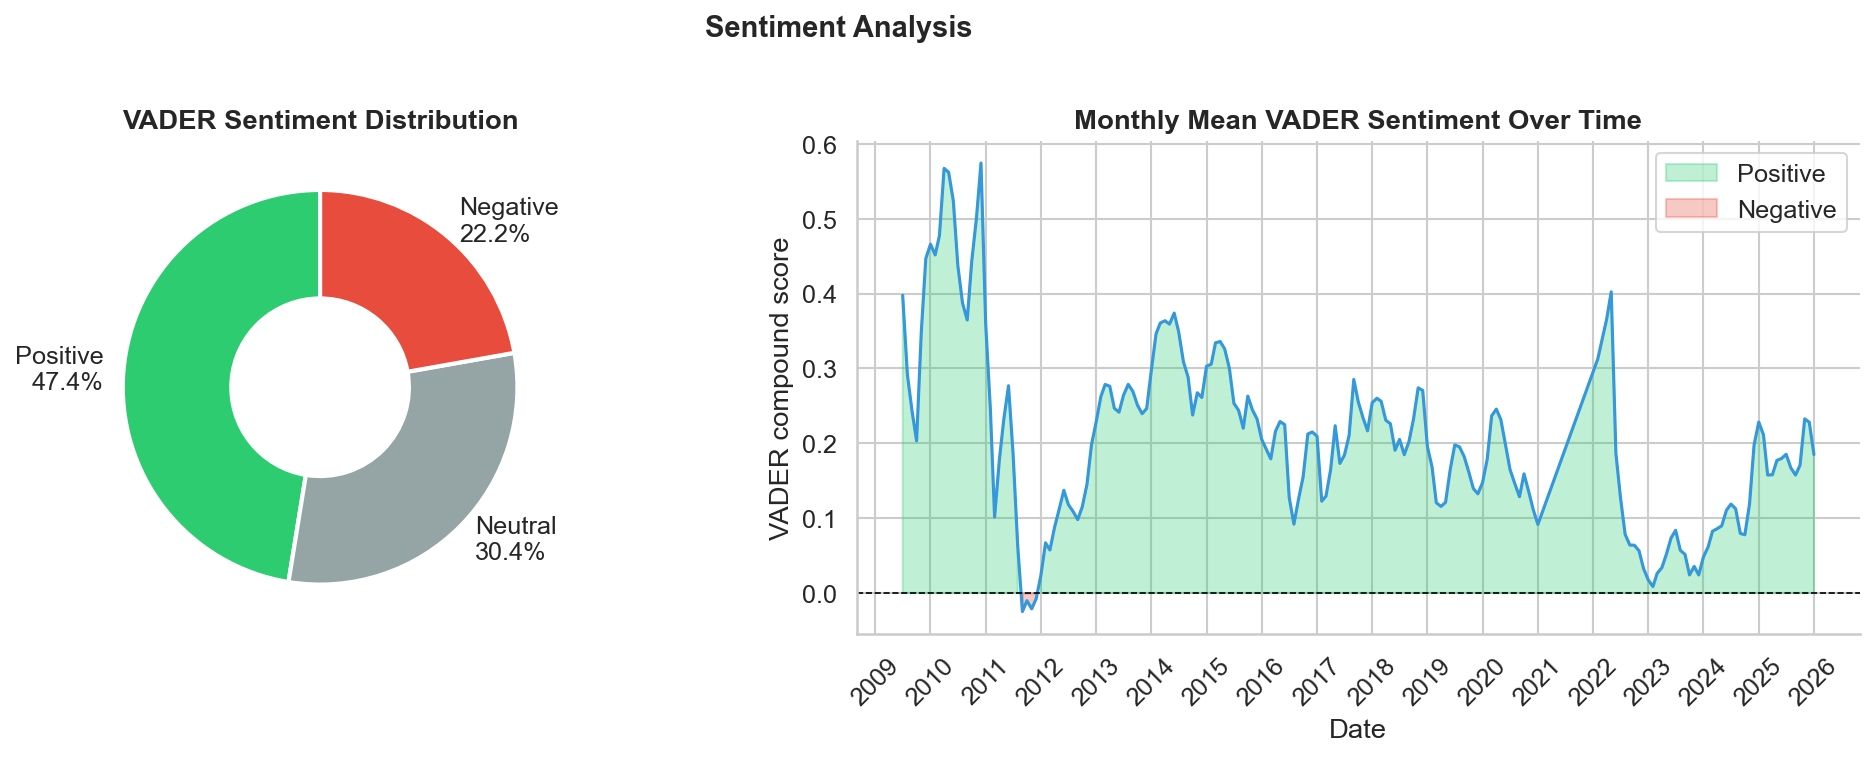

  Positive      35,456  (47.4%)
  Neutral       22,687  (30.4%)
  Negative      16,599  (22.2%)

VADER / FinBERT label agreement: 46.3%


In [7]:
# ── Sentiment label counts ────────────────────────────────────────────────────
if "vader_label" in tweets.columns:
    label_counts = tweets["vader_label"].value_counts()
    labels  = ["positive", "neutral", "negative"]
    counts  = [label_counts.get(l, 0) for l in labels]
    colors  = [SENTIMENT_PALETTE[l] for l in labels]
    pcts    = [100 * c / sum(counts) for c in counts]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: donut chart
    wedges, texts, autotexts = axes[0].pie(
        counts, labels=[f"{l.capitalize()}\n{p:.1f}%" for l, p in zip(labels, pcts)],
        colors=colors, autopct="", startangle=90,
        wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 2}
    )
    axes[0].set_title("VADER Sentiment Distribution", fontweight="bold")

    # Right: sentiment trend over time (monthly rolling mean)
    monthly_sent = (tweets.groupby("month")["vader_compound"]
                    .mean().rolling(3).mean().reset_index())
    axes[1].fill_between(monthly_sent["month"], monthly_sent["vader_compound"],
                          where=monthly_sent["vader_compound"] >= 0,
                          alpha=0.3, color=C_POSITIVE, label="Positive")
    axes[1].fill_between(monthly_sent["month"], monthly_sent["vader_compound"],
                          where=monthly_sent["vader_compound"] < 0,
                          alpha=0.3, color=C_NEGATIVE, label="Negative")
    axes[1].plot(monthly_sent["month"], monthly_sent["vader_compound"],
                 color=C_ACCENT, linewidth=1.5)
    axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_title("Monthly Mean VADER Sentiment Over Time", fontweight="bold")
    axes[1].set_xlabel("Date"); axes[1].set_ylabel("VADER compound score")
    axes[1].xaxis.set_major_locator(mdates.YearLocator())
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(axes[1].get_xticklabels(), rotation=45)
    axes[1].legend()

    plt.suptitle("Sentiment Analysis", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    savefig("04_sentiment_distributions")
    plt.show()

    for l, c, p in zip(labels, counts, pcts):
        print(f"  {l.capitalize():<12} {c:>7,}  ({p:.1f}%)")

# ── VADER vs FinBERT agreement ─────────────────────────────────────────────────
if "finbert_label" in tweets.columns and tweets["finbert_label"].notna().any():
    agree = (tweets["vader_label"] == tweets["finbert_label"]).mean()
    print(f"\nVADER / FinBERT label agreement: {100*agree:.1f}%")


  Saved: 04b_finbert_sentiment_distributions.png


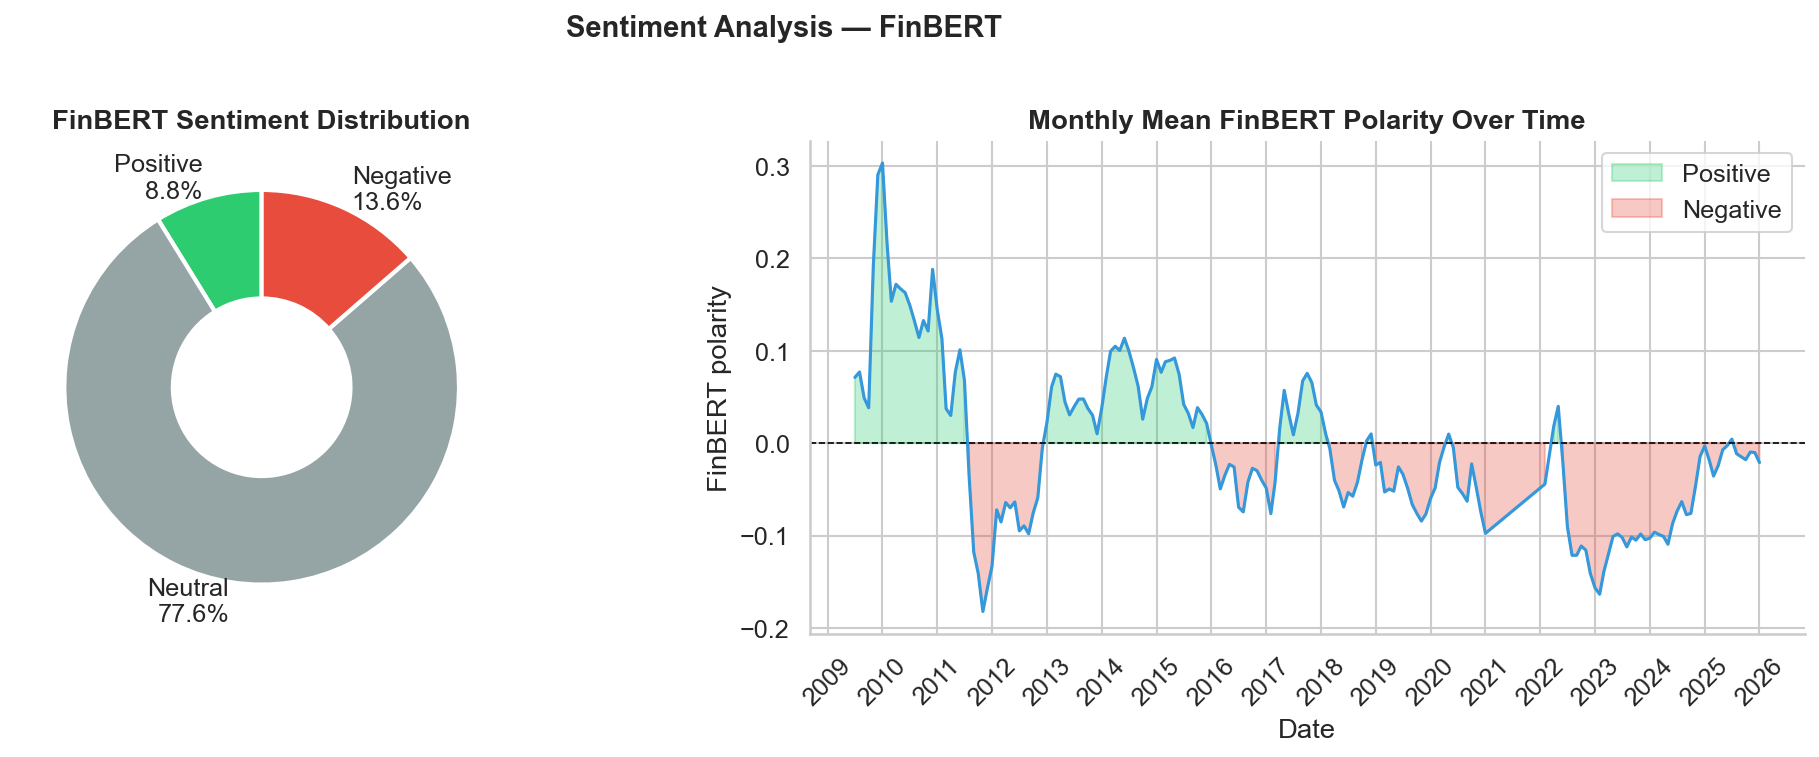

  Positive       6,583  (8.8%)
  Neutral       57,983  (77.6%)
  Negative      10,176  (13.6%)


In [20]:
# ── FinBERT sentiment label counts and trend ───────────────────────────────────
if "finbert_label" in tweets.columns and tweets["finbert_label"].notna().any():
    label_counts = tweets["finbert_label"].value_counts()
    labels  = ["positive", "neutral", "negative"]
    counts  = [label_counts.get(l, 0) for l in labels]
    colors  = [SENTIMENT_PALETTE[l] for l in labels]
    pcts    = [100 * c / sum(counts) for c in counts]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: donut chart
    wedges, texts, autotexts = axes[0].pie(
        counts, labels=[f"{l.capitalize()}\n{p:.1f}%" for l, p in zip(labels, pcts)],
        colors=colors, autopct="", startangle=90,
        wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 2}
    )
    axes[0].set_title("FinBERT Sentiment Distribution", fontweight="bold")

    # Right: sentiment trend over time (monthly rolling mean)
    monthly_sent = (tweets.groupby("month")["finbert_polarity"]
                    .mean().rolling(3).mean().reset_index())
    axes[1].fill_between(monthly_sent["month"], monthly_sent["finbert_polarity"],
                          where=monthly_sent["finbert_polarity"] >= 0,
                          alpha=0.3, color=C_POSITIVE, label="Positive")
    axes[1].fill_between(monthly_sent["month"], monthly_sent["finbert_polarity"],
                          where=monthly_sent["finbert_polarity"] < 0,
                          alpha=0.3, color=C_NEGATIVE, label="Negative")
    axes[1].plot(monthly_sent["month"], monthly_sent["finbert_polarity"],
                 color=C_ACCENT, linewidth=1.5)
    axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_title("Monthly Mean FinBERT Polarity Over Time", fontweight="bold")
    axes[1].set_xlabel("Date"); axes[1].set_ylabel("FinBERT polarity")
    axes[1].xaxis.set_major_locator(mdates.YearLocator())
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(axes[1].get_xticklabels(), rotation=45)
    axes[1].legend()

    plt.suptitle("Sentiment Analysis — FinBERT", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    savefig("04b_finbert_sentiment_distributions")
    plt.show()

    for l, c, p in zip(labels, counts, pcts):
        print(f"  {l.capitalize():<12} {c:>7,}  ({p:.1f}%)")

else:
    print("FinBERT sentiment labels not available in tweets.")


---
## 7 — Platform Comparison: Twitter vs Truth Social

Trump's suspension from Twitter in January 2021 created a natural experiment.
Truth Social posts are longer, more capitalised, and have lower average sentiment
— consistent with a less moderated, more politically charged environment.


Platform comparison:
    platform  post_count  vader_mean  vader_std  likes_median  word_count_mean  caps_ratio_mean
Truth Social       26014      0.0975     0.4933    10461.5000          27.1578           0.1767
     Twitter       48728      0.2191     0.5375     1065.0000          19.6468           0.1151
  Saved: 05_platform_comparison.png


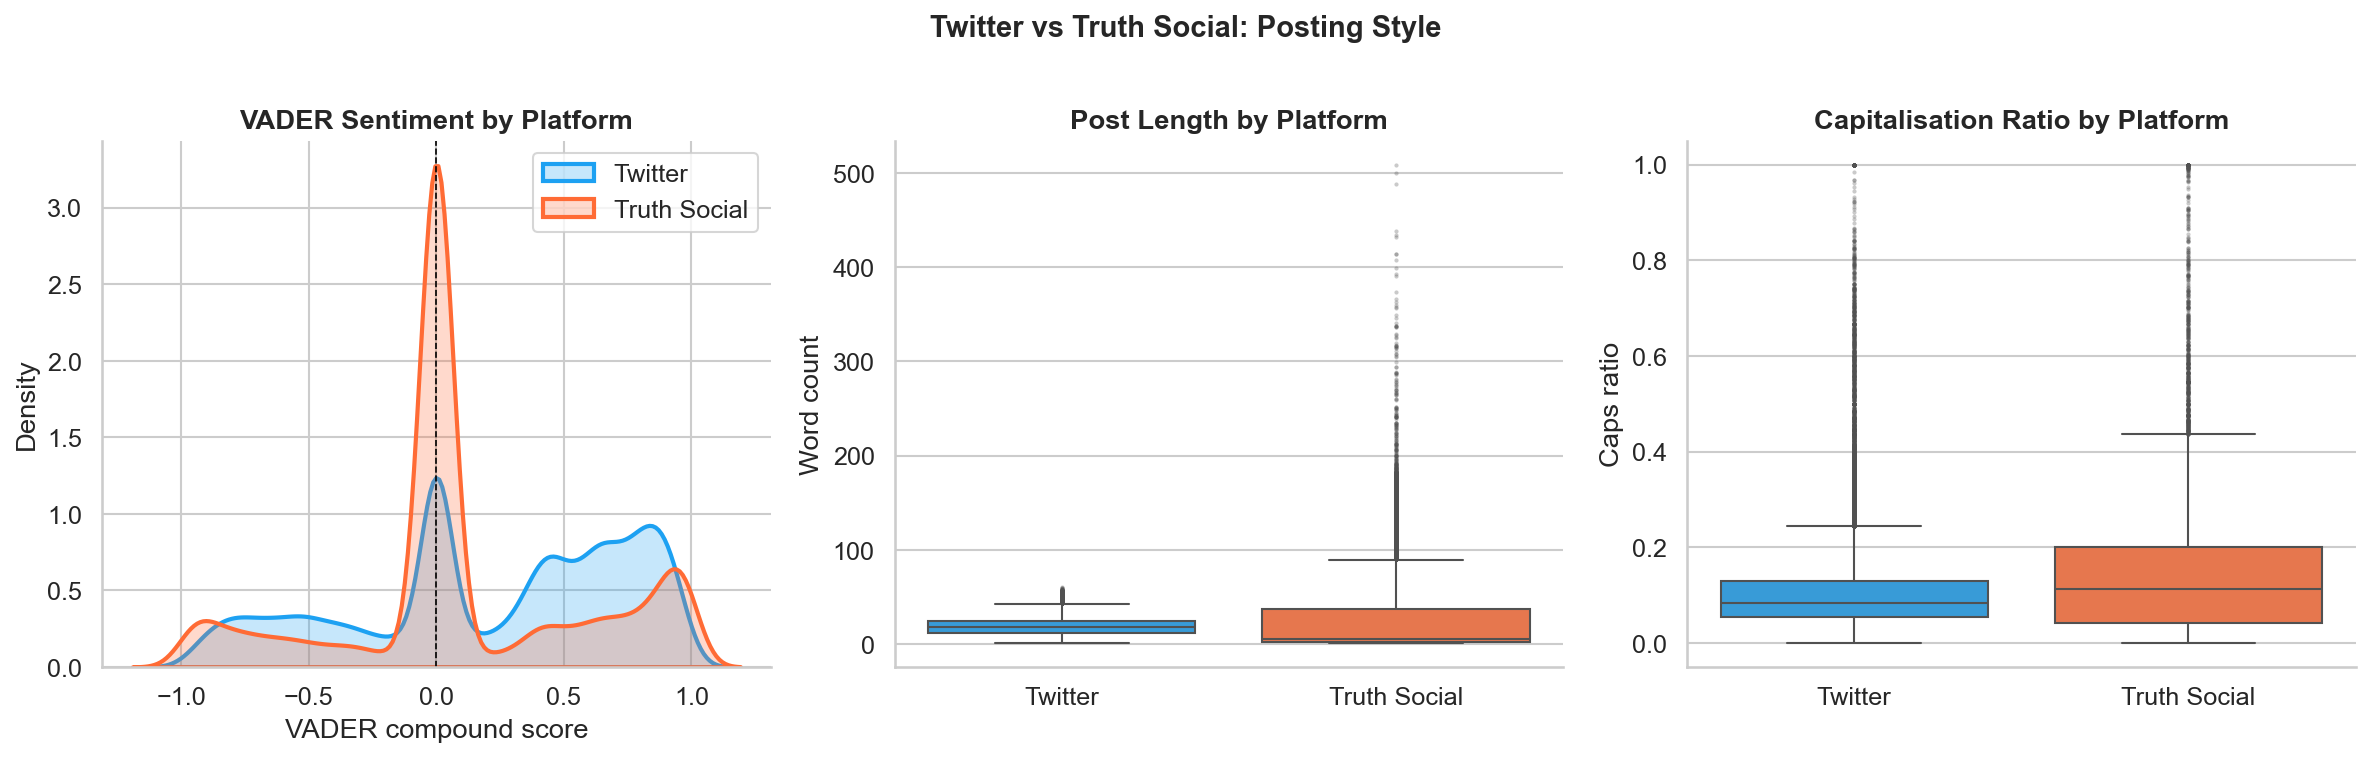

In [8]:
if "platform" in tweets.columns:
    plat_stats = tweets.groupby("platform").agg(
        post_count      = ("text", "count"),
        vader_mean      = ("vader_compound", "mean"),
        vader_std       = ("vader_compound", "std"),
        likes_median    = ("favorite_count", "median"),
        word_count_mean = ("word_count", "mean"),
        caps_ratio_mean = ("caps_ratio", "mean"),
    ).reset_index()
    print("Platform comparison:")
    print(plat_stats.to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    platform_colors = {"Twitter": C_TWITTER, "Truth Social": C_TRUTH}

    # Left: VADER distribution by platform
    for plat, col in platform_colors.items():
        sub = tweets[tweets["platform"] == plat]["vader_compound"].dropna()
        sns.kdeplot(sub, ax=axes[0], color=col, label=plat, linewidth=2, fill=True, alpha=0.25)
    axes[0].set_title("VADER Sentiment by Platform", fontweight="bold")
    axes[0].set_xlabel("VADER compound score")
    axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
    axes[0].legend()

    # Middle: word count comparison
    sns.boxplot(data=tweets, x="platform", y="word_count",
                palette=platform_colors, ax=axes[1],
                order=["Twitter", "Truth Social"],
                flierprops={"marker": ".", "markersize": 2, "alpha": 0.3})
    axes[1].set_title("Post Length by Platform", fontweight="bold")
    axes[1].set_xlabel(""); axes[1].set_ylabel("Word count")

    # Right: caps ratio comparison
    sns.boxplot(data=tweets, x="platform", y="caps_ratio",
                palette=platform_colors, ax=axes[2],
                order=["Twitter", "Truth Social"],
                flierprops={"marker": ".", "markersize": 2, "alpha": 0.3})
    axes[2].set_title("Capitalisation Ratio by Platform", fontweight="bold")
    axes[2].set_xlabel(""); axes[2].set_ylabel("Caps ratio")

    plt.suptitle("Twitter vs Truth Social: Posting Style", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    savefig("05_platform_comparison")
    plt.show()


  Saved: 05b_topic_share_by_platform.png


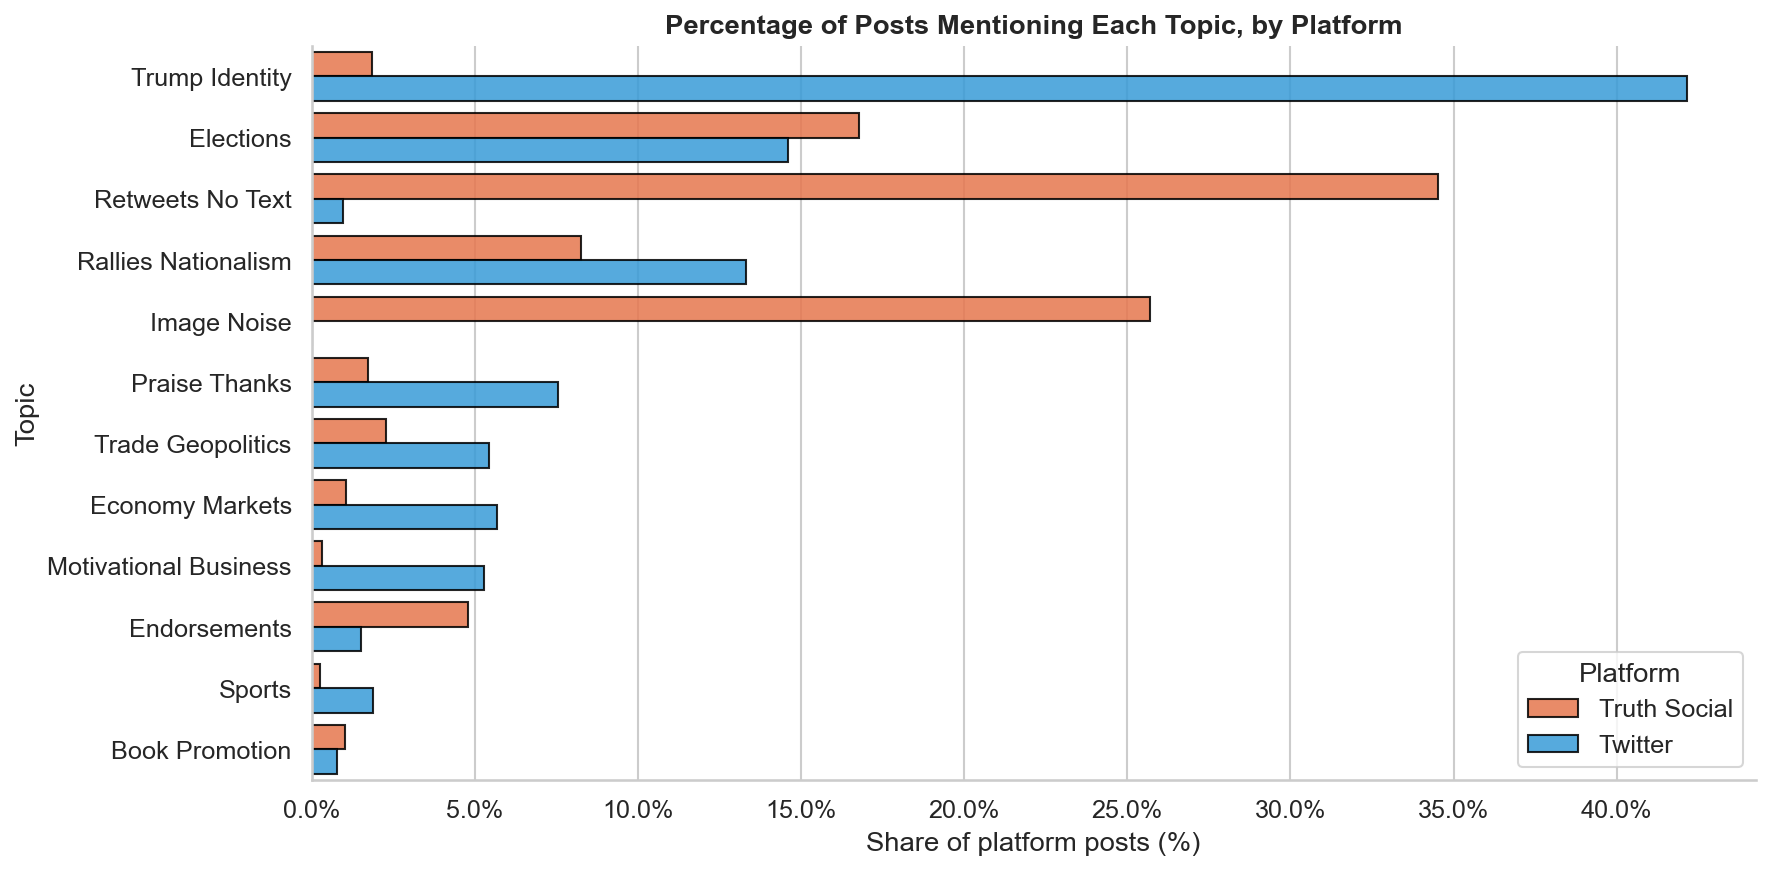

In [24]:
import matplotlib.ticker as mtick

# ── Topic share by platform ──────────────────────────────────────────────────
if "platform" in tweets.columns:
    topic_col = "bertopic_label" if "bertopic_label" in tweets.columns else "cluster_label"
    if topic_col in tweets.columns:
        BERTOPIC_THEME_MAP = {
            0:  "topic_trump_identity",
            1:  "topic_elections",
            2:  "retweets_no_text",
            3:  "topic_rallies_nationalism",
            4:  "image_noise",
            5:  "topic_praise_thanks",
            6:  "topic_trade_geopolitics",
            7:  "topic_economy_markets",
            8:  "topic_motivational_business",
            9:  "topic_endorsements",
            10: "topic_sports",
            11: "topic_book_promotion",
            12: "topic_energy_environment",
            13: "topic_mitt_dinner"
        }

        id_to_name = {
            f"topic_{k}": v.replace("topic_", "").replace("_", " ").title()
            for k, v in BERTOPIC_THEME_MAP.items()
        }

        def friendly_label(raw):
            raw = str(raw)
            return id_to_name.get(raw, raw.replace("topic_", "Topic ").replace("_", " ").title())

        count_df = (
            tweets[tweets[topic_col] != "outlier"]
            .groupby(["platform", topic_col])
            .size()
            .reset_index(name="count")
        )

        if len(count_df):
            count_df["pct"] = 100 * count_df["count"] / count_df.groupby("platform")["count"].transform("sum")
            top_topics = (
                count_df.groupby(topic_col)["count"].sum()
                .sort_values(ascending=False)
                .head(12)
                .index
            )
            plot_df = count_df[count_df[topic_col].isin(top_topics)].copy()
            plot_df[topic_col] = plot_df[topic_col].apply(friendly_label)
            order = (
                plot_df.groupby(topic_col)["count"].sum()
                .sort_values(ascending=False)
                .index
            )

            fig, ax = plt.subplots(figsize=(12, 6))
            sns.barplot(
                data=plot_df,
                x="pct",
                y=topic_col,
                hue="platform",
                order=order,
                palette={"Twitter": C_TWITTER, "Truth Social": C_TRUTH},
                ci=None,
                edgecolor="black",
                alpha=0.85,
                ax=ax,
            )
            ax.set_title("Percentage of Posts Mentioning Each Topic, by Platform", fontweight="bold")
            ax.set_xlabel("Share of platform posts (%)")
            ax.set_ylabel("Topic")
            ax.xaxis.set_major_formatter(mtick.PercentFormatter())
            ax.legend(title="Platform", loc="lower right")
            plt.tight_layout()
            savefig("05b_topic_share_by_platform")
            plt.show()
        else:
            print("No topic mentions available for platform breakdown.")
    else:
        print(f"Topic column not found: {topic_col}")
else:
    print("Platform column missing in tweets.")


---
## 8 — Sentiment vs S&P 500

The core question: does Trump's sentiment co-move with market returns?
A dual-axis plot overlays monthly sentiment with the cumulative S&P 500 return.
A scatter plot shows the daily relationship between sentiment and next-day return.


  Saved: 06_sentiment_vs_market.png


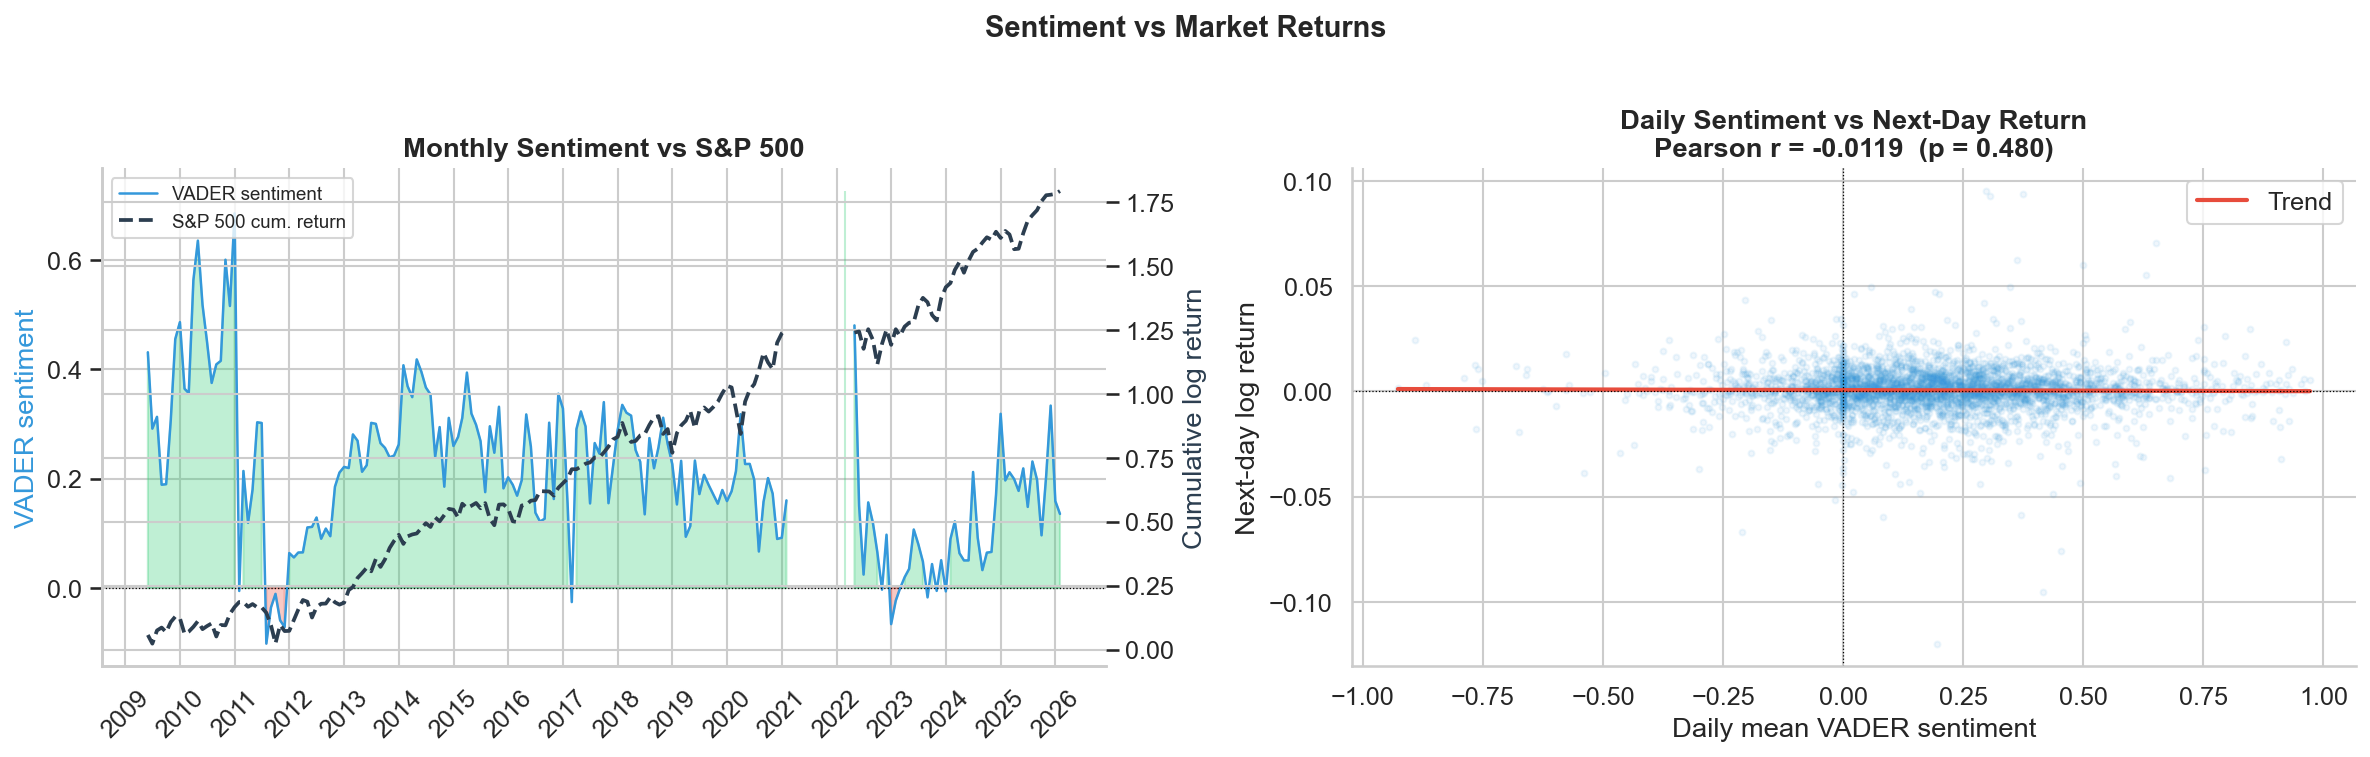

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: dual-axis sentiment vs cumulative return
if "vader_mean" in fm.columns and "log_return" in fm.columns:
    fm_sorted = fm.sort_values("date_only").copy()
    fm_sorted["cum_return"] = fm_sorted["log_return"].cumsum()
    monthly_fm = fm_sorted.set_index("date_only").resample("ME").agg(
        vader_mean=("vader_mean", "mean"),
        cum_return=("cum_return", "last")
    ).reset_index()

    ax1 = axes[0]
    ax2 = ax1.twinx()
    ax1.fill_between(monthly_fm["date_only"], monthly_fm["vader_mean"],
                     where=monthly_fm["vader_mean"] >= 0,
                     alpha=0.3, color=C_POSITIVE)
    ax1.fill_between(monthly_fm["date_only"], monthly_fm["vader_mean"],
                     where=monthly_fm["vader_mean"] < 0,
                     alpha=0.3, color=C_NEGATIVE)
    ax1.plot(monthly_fm["date_only"], monthly_fm["vader_mean"],
             color=C_ACCENT, linewidth=1.2, label="VADER sentiment")
    ax2.plot(monthly_fm["date_only"], monthly_fm["cum_return"],
             color=C_SP500, linewidth=1.8, linestyle="--", label="S&P 500 cum. return")
    ax1.axhline(0, color="black", linewidth=0.6, linestyle=":")
    ax1.set_ylabel("VADER sentiment", color=C_ACCENT)
    ax2.set_ylabel("Cumulative log return", color=C_SP500)
    ax1.set_title("Monthly Sentiment vs S&P 500", fontweight="bold")
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax1.get_xticklabels(), rotation=45)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

# Right: scatter — sentiment vs next-day return
if "vader_mean" in fm.columns and "next_log_return" in fm.columns:
    scatter_df = fm[["vader_mean", "next_log_return"]].dropna()
    axes[1].scatter(scatter_df["vader_mean"], scatter_df["next_log_return"],
                    alpha=0.08, s=8, color=C_ACCENT)
    # Trend line
    m, b = np.polyfit(scatter_df["vader_mean"], scatter_df["next_log_return"], 1)
    x_line = np.linspace(scatter_df["vader_mean"].min(), scatter_df["vader_mean"].max(), 100)
    axes[1].plot(x_line, m * x_line + b, color=C_NEGATIVE, linewidth=2, label="Trend")
    r, p = stats.pearsonr(scatter_df["vader_mean"], scatter_df["next_log_return"])
    axes[1].set_title(f"Daily Sentiment vs Next-Day Return\nPearson r = {r:+.4f}  (p = {p:.3f})",
                      fontweight="bold")
    axes[1].set_xlabel("Daily mean VADER sentiment")
    axes[1].set_ylabel("Next-day log return")
    axes[1].axhline(0, color="black", linewidth=0.6, linestyle=":")
    axes[1].axvline(0, color="black", linewidth=0.6, linestyle=":")
    axes[1].legend()

plt.suptitle("Sentiment vs Market Returns", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
savefig("06_sentiment_vs_market")
plt.show()


  Saved: 06b_finbert_sentiment_vs_market.png


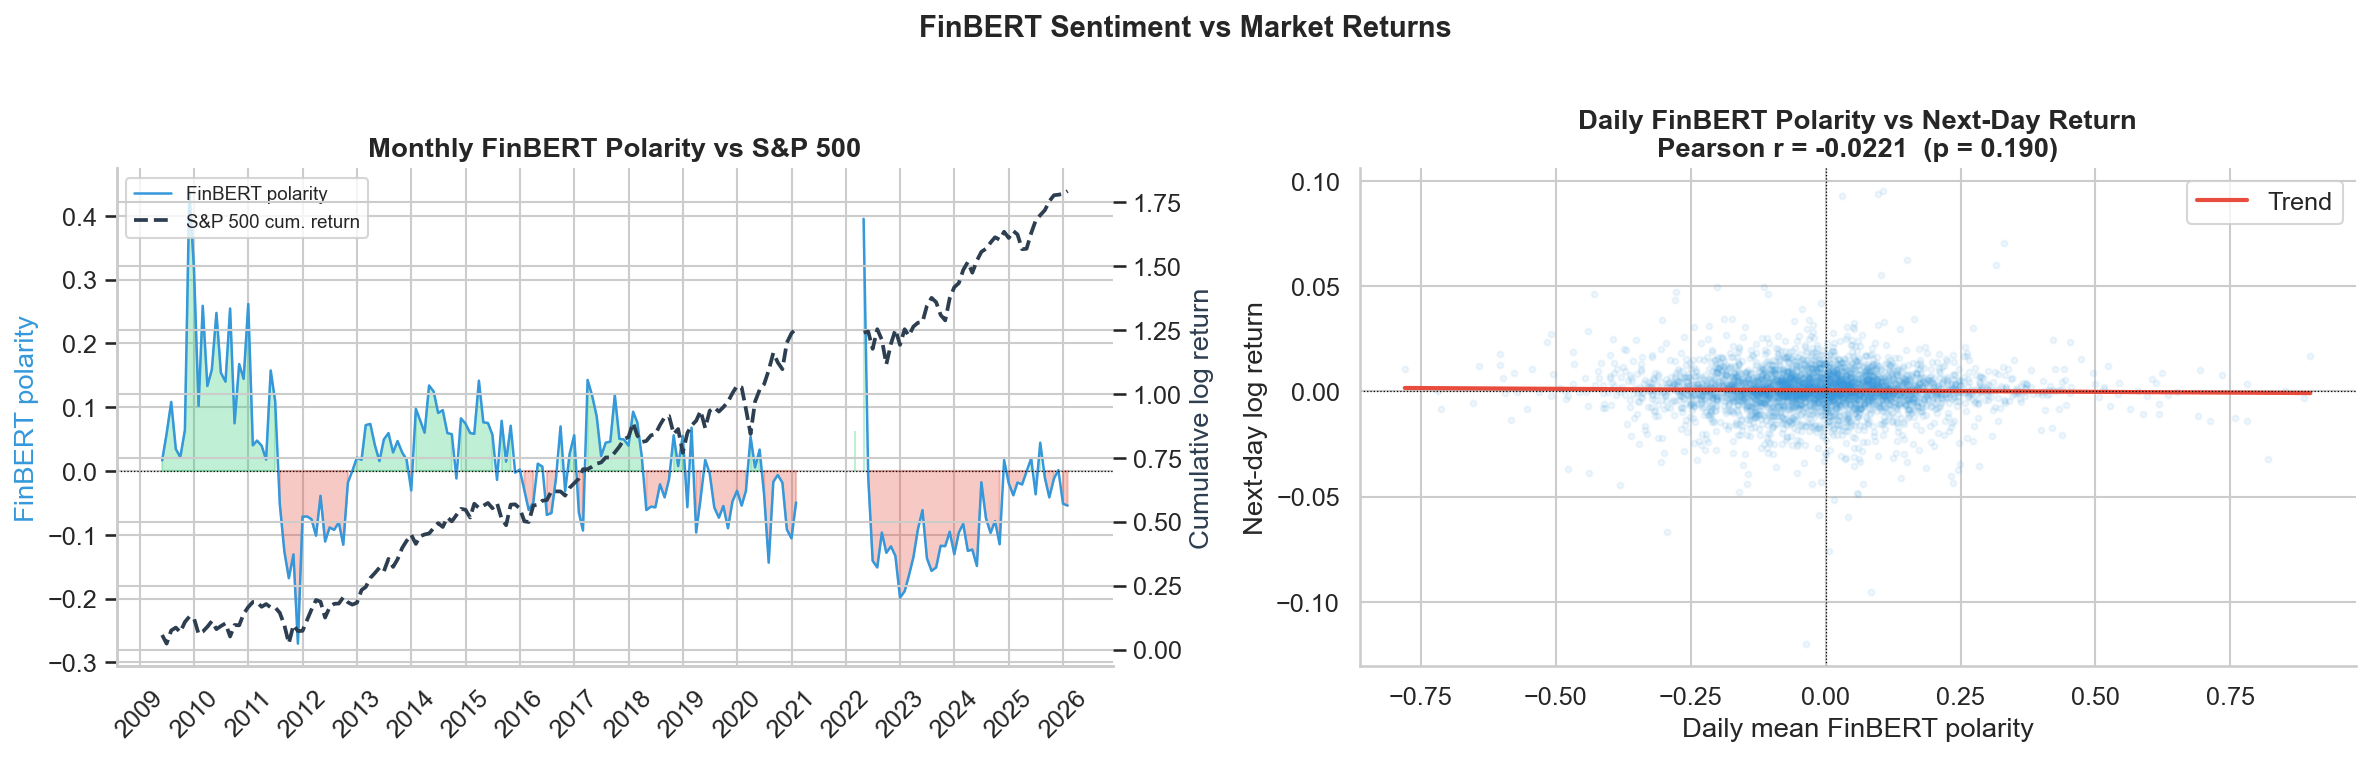

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: dual-axis FinBERT polarity vs cumulative return
if "finbert_mean" in fm.columns and "log_return" in fm.columns:
    fm_sorted = fm.sort_values("date_only").copy()
    fm_sorted["cum_return"] = fm_sorted["log_return"].cumsum()
    monthly_fm = fm_sorted.set_index("date_only").resample("ME").agg(
        finbert_mean=("finbert_mean", "mean"),
        cum_return=("cum_return", "last")
    ).reset_index()

    ax1 = axes[0]
    ax2 = ax1.twinx()
    ax1.fill_between(monthly_fm["date_only"], monthly_fm["finbert_mean"],
                     where=monthly_fm["finbert_mean"] >= 0,
                     alpha=0.3, color=C_POSITIVE)
    ax1.fill_between(monthly_fm["date_only"], monthly_fm["finbert_mean"],
                     where=monthly_fm["finbert_mean"] < 0,
                     alpha=0.3, color=C_NEGATIVE)
    ax1.plot(monthly_fm["date_only"], monthly_fm["finbert_mean"],
             color=C_ACCENT, linewidth=1.2, label="FinBERT polarity")
    ax2.plot(monthly_fm["date_only"], monthly_fm["cum_return"],
             color=C_SP500, linewidth=1.8, linestyle="--", label="S&P 500 cum. return")
    ax1.axhline(0, color="black", linewidth=0.6, linestyle=":")
    ax1.set_ylabel("FinBERT polarity", color=C_ACCENT)
    ax2.set_ylabel("Cumulative log return", color=C_SP500)
    ax1.set_title("Monthly FinBERT Polarity vs S&P 500", fontweight="bold")
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax1.get_xticklabels(), rotation=45)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

# Right: scatter — FinBERT polarity vs next-day return
if "finbert_mean" in fm.columns and "next_log_return" in fm.columns:
    scatter_df = fm[["finbert_mean", "next_log_return"]].dropna()
    axes[1].scatter(scatter_df["finbert_mean"], scatter_df["next_log_return"],
                    alpha=0.08, s=8, color=C_ACCENT)
    m, b = np.polyfit(scatter_df["finbert_mean"], scatter_df["next_log_return"], 1)
    x_line = np.linspace(scatter_df["finbert_mean"].min(), scatter_df["finbert_mean"].max(), 100)
    axes[1].plot(x_line, m * x_line + b, color=C_NEGATIVE, linewidth=2, label="Trend")
    r, p = stats.pearsonr(scatter_df["finbert_mean"], scatter_df["next_log_return"])
    axes[1].set_title(f"Daily FinBERT Polarity vs Next-Day Return\nPearson r = {r:+.4f}  (p = {p:.3f})",
                      fontweight="bold")
    axes[1].set_xlabel("Daily mean FinBERT polarity")
    axes[1].set_ylabel("Next-day log return")
    axes[1].axhline(0, color="black", linewidth=0.6, linestyle=":")
    axes[1].axvline(0, color="black", linewidth=0.6, linestyle=":")
    axes[1].legend()

plt.suptitle("FinBERT Sentiment vs Market Returns", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
savefig("06b_finbert_sentiment_vs_market")
plt.show()


---
## 9 — Correlation Structure

Which features correlate most with next-day log return?
We show a horizontal bar chart of the top correlations — cleaner and more readable
than a full heatmap for a report.


  Saved: 07_correlations.png


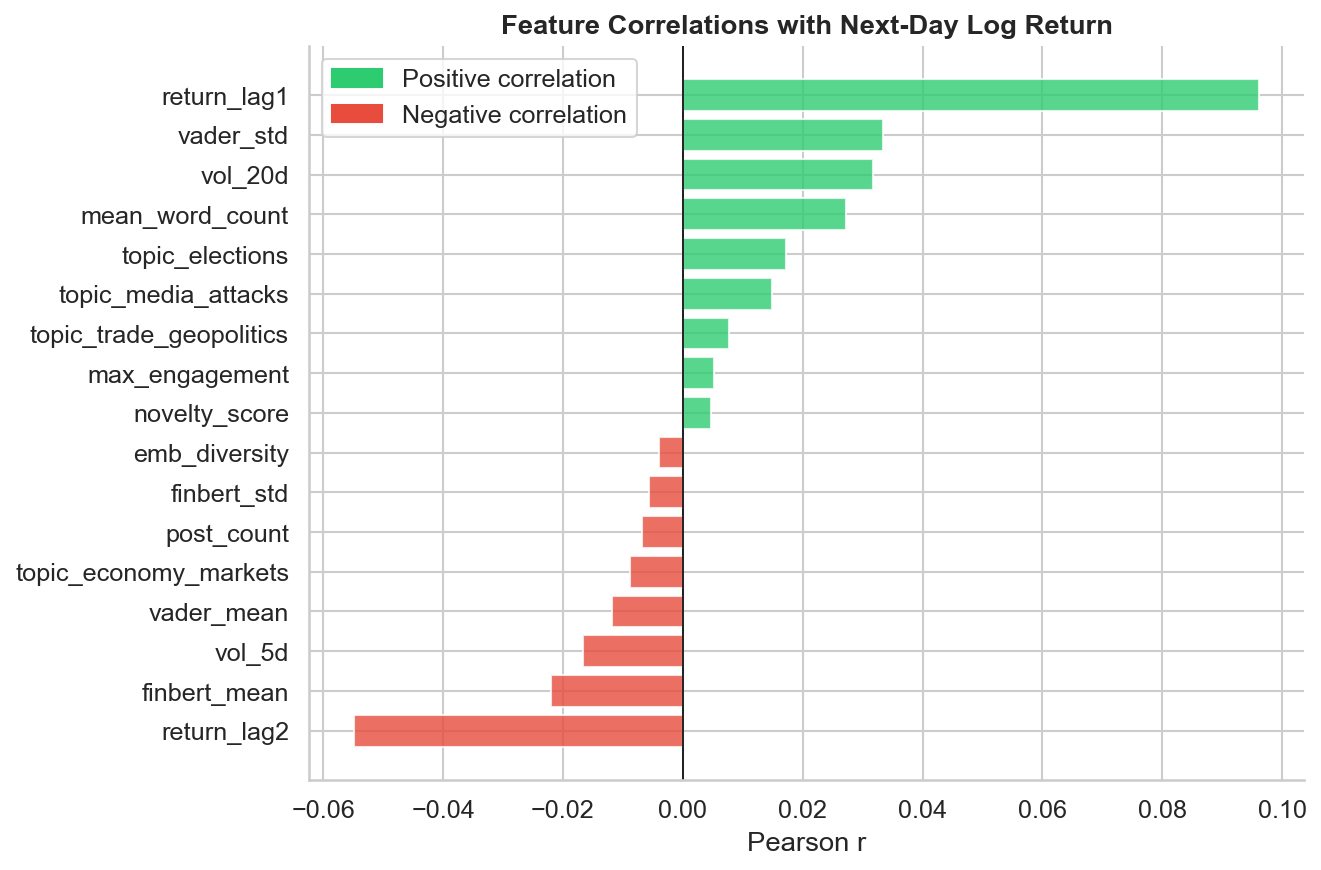


Top correlations with next_log_return:
return_lag1           0.0962
return_lag2           0.0548
vader_std             0.0333
vol_20d               0.0318
mean_word_count       0.0272
finbert_mean          0.0221
topic_elections       0.0172
vol_5d                0.0167
topic_media_attacks   0.0148
vader_mean            0.0119
Name: next_log_return, dtype: float64


In [10]:
corr_cols = [c for c in [
    "vader_mean", "vader_std", "finbert_mean", "finbert_std",
    "post_count", "max_engagement", "mean_word_count",
    "novelty_score", "emb_diversity",
    "vol_5d", "vol_20d", "return_lag1", "return_lag2",
    "topic_trade_geopolitics", "topic_economy_markets",
    "topic_elections", "topic_media_attacks",
] if c in fm.columns]

if "next_log_return" in fm.columns and corr_cols:
    corr_vals = fm[corr_cols + ["next_log_return"]].corr()["next_log_return"].drop("next_log_return")
    corr_vals = corr_vals.sort_values()
    colors_bar = [C_POSITIVE if v > 0 else C_NEGATIVE for v in corr_vals]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(corr_vals.index, corr_vals.values, color=colors_bar, alpha=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Feature Correlations with Next-Day Log Return", fontweight="bold")
    ax.set_xlabel("Pearson r")
    pos_patch = mpatches.Patch(color=C_POSITIVE, label="Positive correlation")
    neg_patch = mpatches.Patch(color=C_NEGATIVE, label="Negative correlation")
    ax.legend(handles=[pos_patch, neg_patch])
    plt.tight_layout()
    savefig("07_correlations")
    plt.show()

    print("\nTop correlations with next_log_return:")
    print(corr_vals.abs().sort_values(ascending=False).head(10).round(4))


---
## 10 — Novelty Score & Embedding Diversity

The novelty score measures how semantically different Trump's posts on a given day
are from his recent baseline. We check whether high-novelty days coincide with
larger market movements.


  Saved: 08_novelty.png


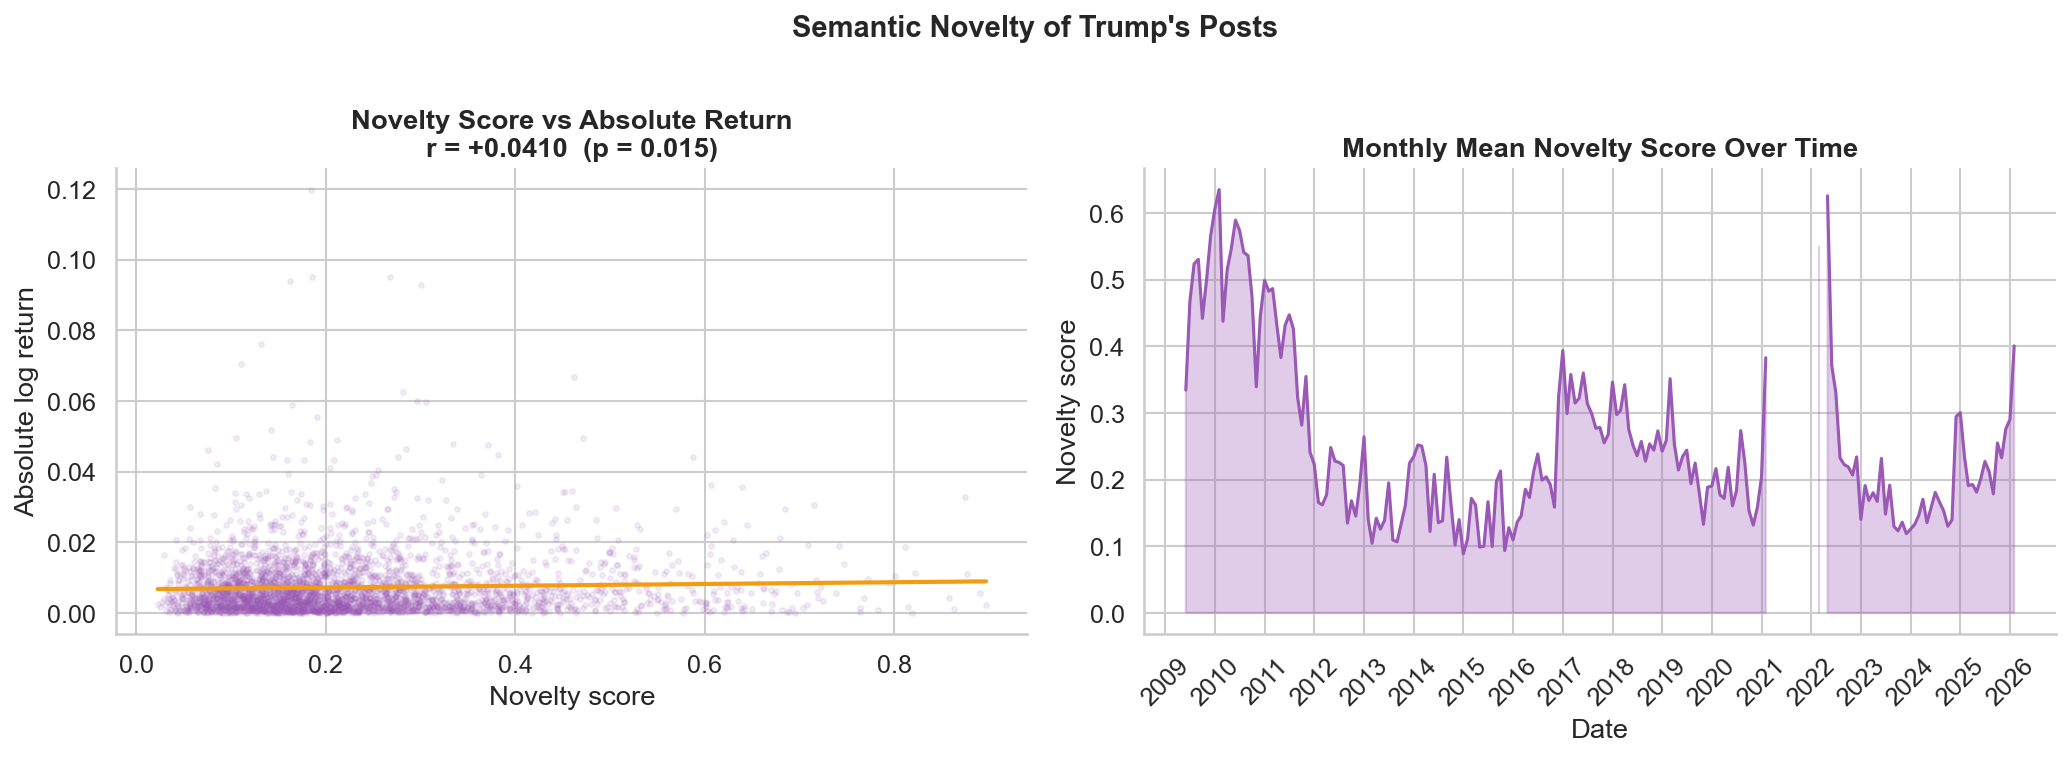

In [11]:
if "novelty_score" in fm.columns and "abs_return" in fm.columns:
    nov_df = fm[["date_only", "novelty_score", "abs_return", "next_log_return"]].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: novelty vs absolute return scatter
    axes[0].scatter(nov_df["novelty_score"], nov_df["abs_return"],
                    alpha=0.1, s=6, color=C_ACCENT2)
    m, b = np.polyfit(nov_df["novelty_score"], nov_df["abs_return"], 1)
    x_l = np.linspace(nov_df["novelty_score"].min(), nov_df["novelty_score"].max(), 100)
    axes[0].plot(x_l, m * x_l + b, color=C_HIGHLIGHT, linewidth=2)
    r, p = stats.pearsonr(nov_df["novelty_score"], nov_df["abs_return"])
    axes[0].set_title(f"Novelty Score vs Absolute Return\nr = {r:+.4f}  (p = {p:.3f})",
                      fontweight="bold")
    axes[0].set_xlabel("Novelty score")
    axes[0].set_ylabel("Absolute log return")

    # Right: novelty over time
    nov_monthly = nov_df.set_index("date_only")["novelty_score"].resample("ME").mean().reset_index()
    axes[1].fill_between(nov_monthly["date_only"], nov_monthly["novelty_score"],
                         alpha=0.3, color=C_ACCENT2)
    axes[1].plot(nov_monthly["date_only"], nov_monthly["novelty_score"],
                 color=C_ACCENT2, linewidth=1.5)
    axes[1].set_title("Monthly Mean Novelty Score Over Time", fontweight="bold")
    axes[1].set_xlabel("Date"); axes[1].set_ylabel("Novelty score")
    axes[1].xaxis.set_major_locator(mdates.YearLocator())
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(axes[1].get_xticklabels(), rotation=45)

    plt.suptitle("Semantic Novelty of Trump's Posts", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    savefig("08_novelty")
    plt.show()


---
## 11 — Key Event Spotlights

We zoom into four historically significant periods and overlay daily VADER sentiment
with the S&P 500 closing price to inspect whether extreme posting coincides with
market movements.


  Saved: 09_event_spotlights.png


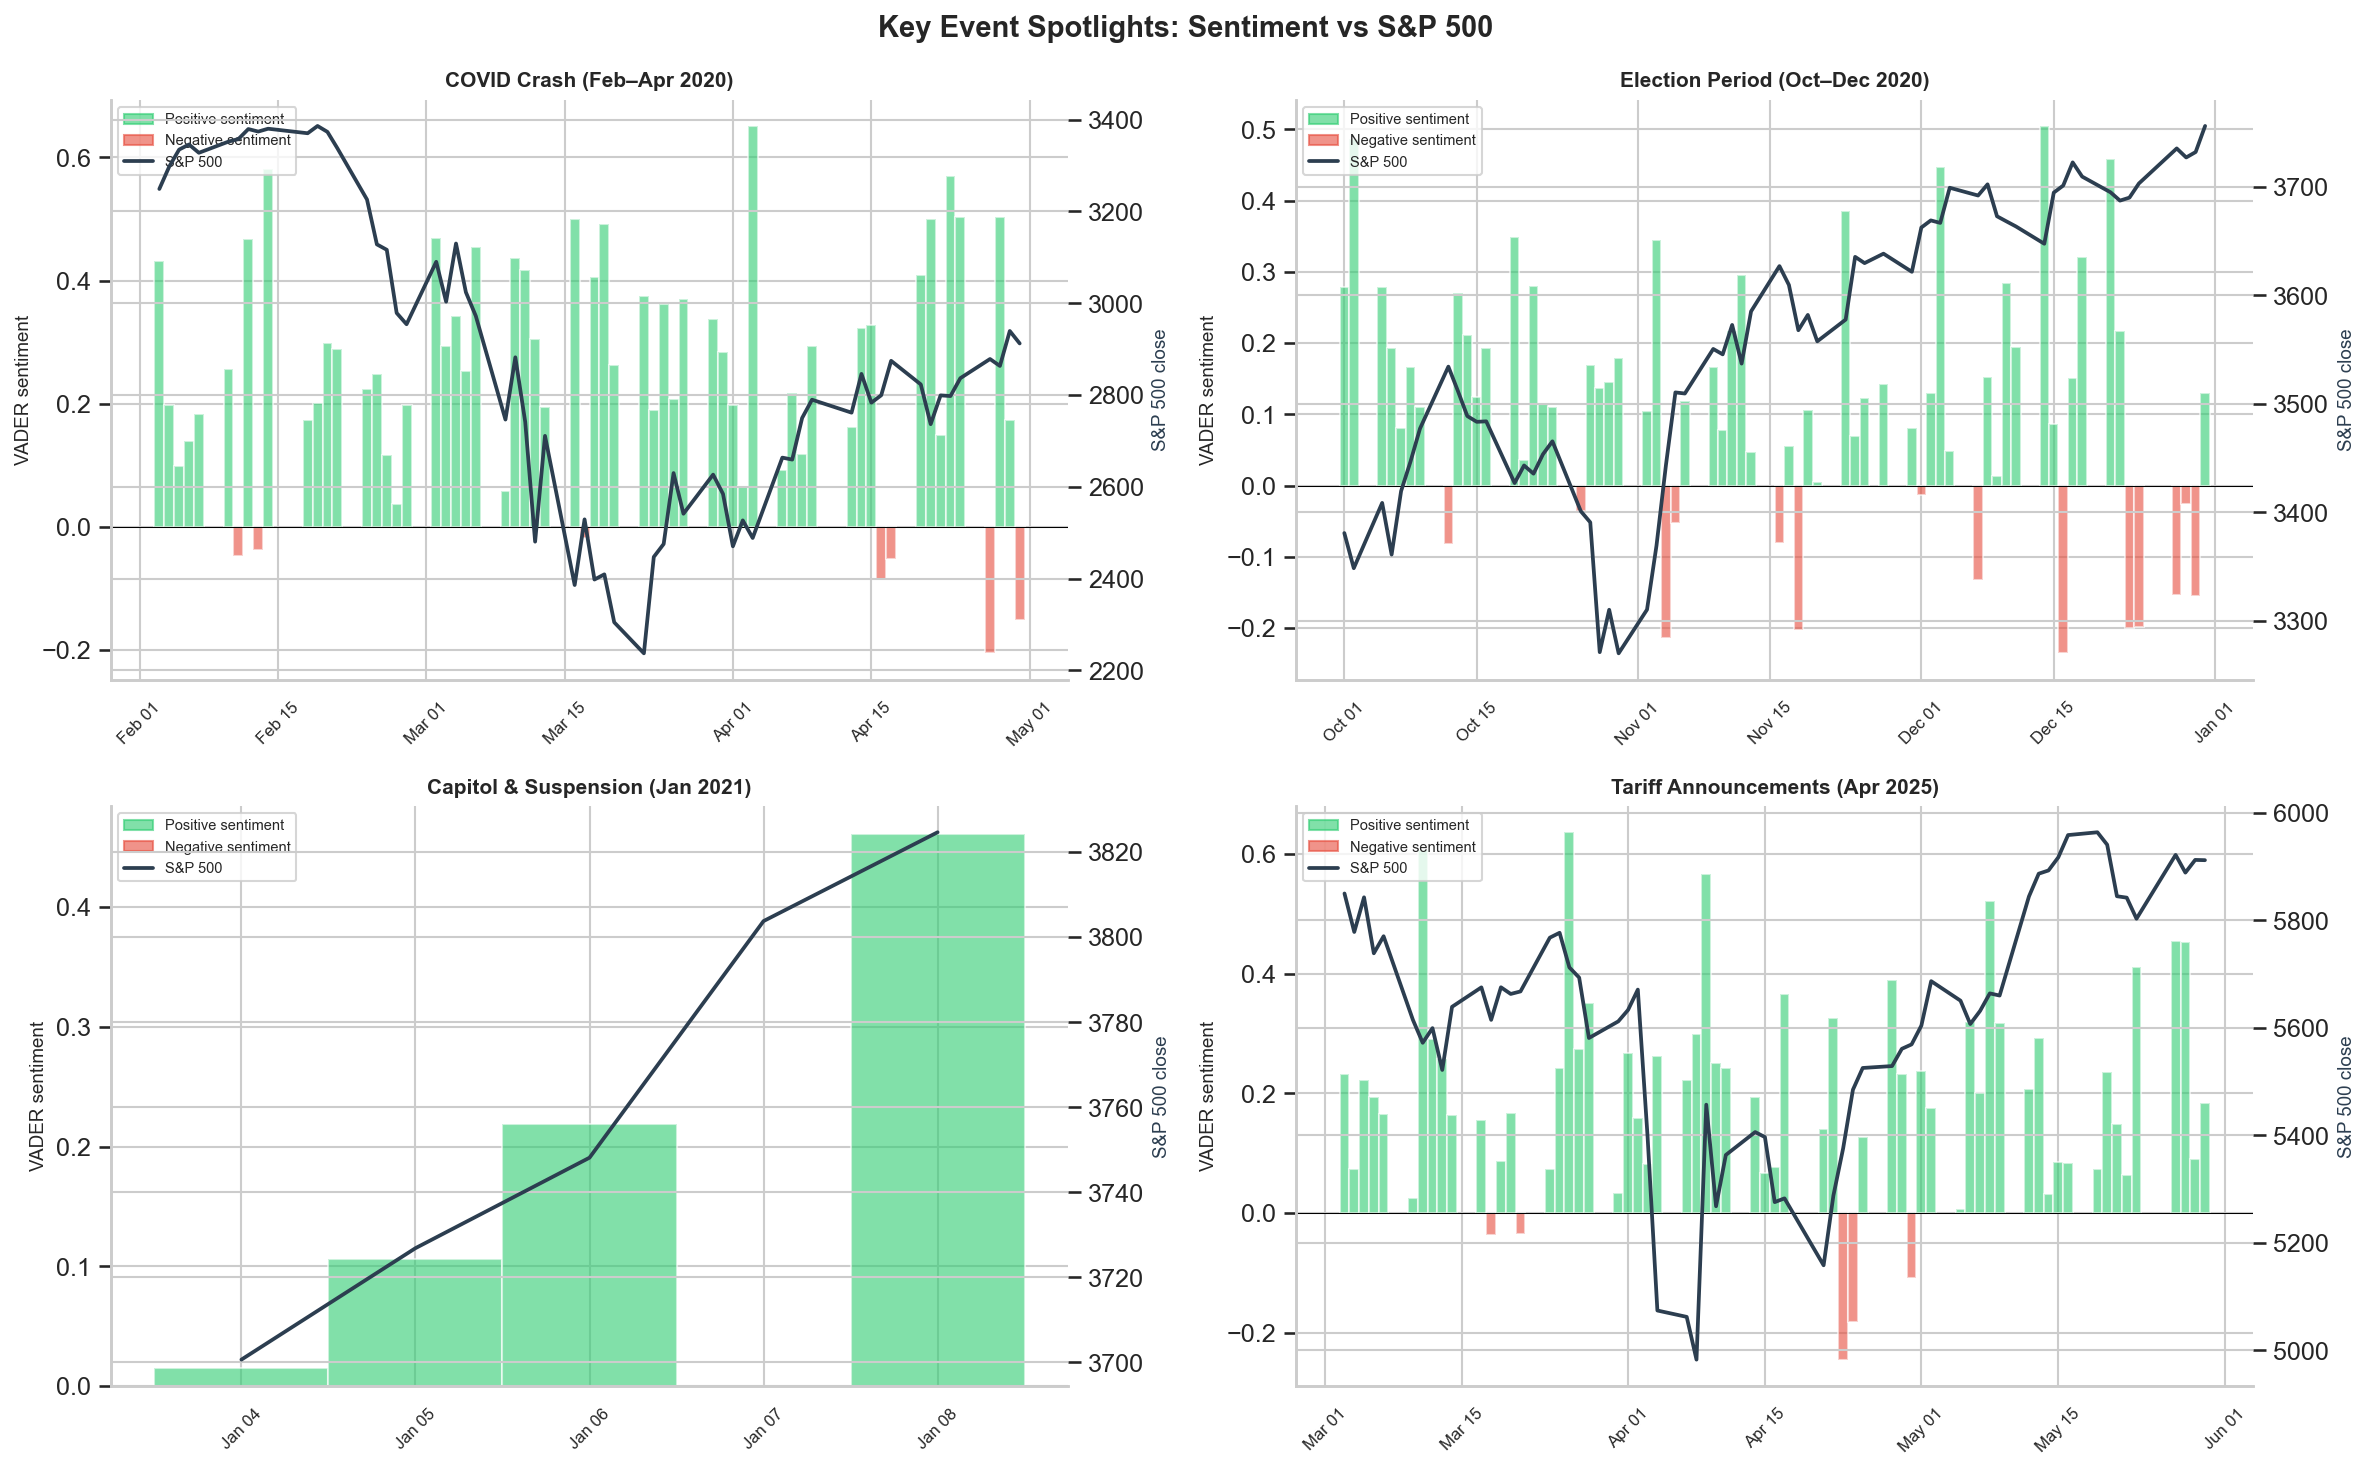

In [12]:
KEY_PERIODS = {
    "COVID Crash (Feb–Apr 2020)":       ("2020-02-01", "2020-04-30"),
    "Election Period (Oct–Dec 2020)":   ("2020-10-01", "2020-12-31"),
    "Capitol & Suspension (Jan 2021)":  ("2021-01-01", "2021-01-31"),
    "Tariff Announcements (Apr 2025)":  ("2025-03-01", "2025-05-31"),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (title, (start, end)) in zip(axes.flat, KEY_PERIODS.items()):
    mask = (fm["date_only"] >= start) & (fm["date_only"] <= end)
    sub  = fm[mask].sort_values("date_only")
    if len(sub) == 0:
        ax.set_visible(False)
        continue

    ax2 = ax.twinx()

    if "vader_mean" in sub.columns:
        ax.bar(sub["date_only"], sub["vader_mean"],
               color=[C_POSITIVE if v >= 0 else C_NEGATIVE for v in sub["vader_mean"]],
               alpha=0.6, width=1)
        ax.axhline(0, color="black", linewidth=0.5)
        ax.set_ylabel("VADER sentiment", fontsize=9)

    if "Close" in sub.columns:
        ax2.plot(sub["date_only"], sub["Close"], color=C_SP500,
                 linewidth=1.8, label="S&P 500")
        ax2.set_ylabel("S&P 500 close", fontsize=9, color=C_SP500)

    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.get_xticklabels(), rotation=45, fontsize=8)

    pos_patch = mpatches.Patch(color=C_POSITIVE, alpha=0.6, label="Positive sentiment")
    neg_patch = mpatches.Patch(color=C_NEGATIVE, alpha=0.6, label="Negative sentiment")
    sp_line   = plt.Line2D([0], [0], color=C_SP500, linewidth=1.8, label="S&P 500")
    ax.legend(handles=[pos_patch, neg_patch, sp_line], fontsize=7, loc="upper left")

plt.suptitle("Key Event Spotlights: Sentiment vs S&P 500", fontsize=14, fontweight="bold")
plt.tight_layout()
savefig("09_event_spotlights")
plt.show()


---
## 12 — Lagged Cross-Correlation Analysis

We compute the Pearson cross-correlation between five signals and S&P 500 log returns
at lags τ ∈ {−5, …, +5} trading days.

- **Positive lag**: tweet signal leads the return → Trump moves markets
- **Negative lag**: market moves before the posts → Trump reacts to markets


  Saved: 10_cross_correlation.png


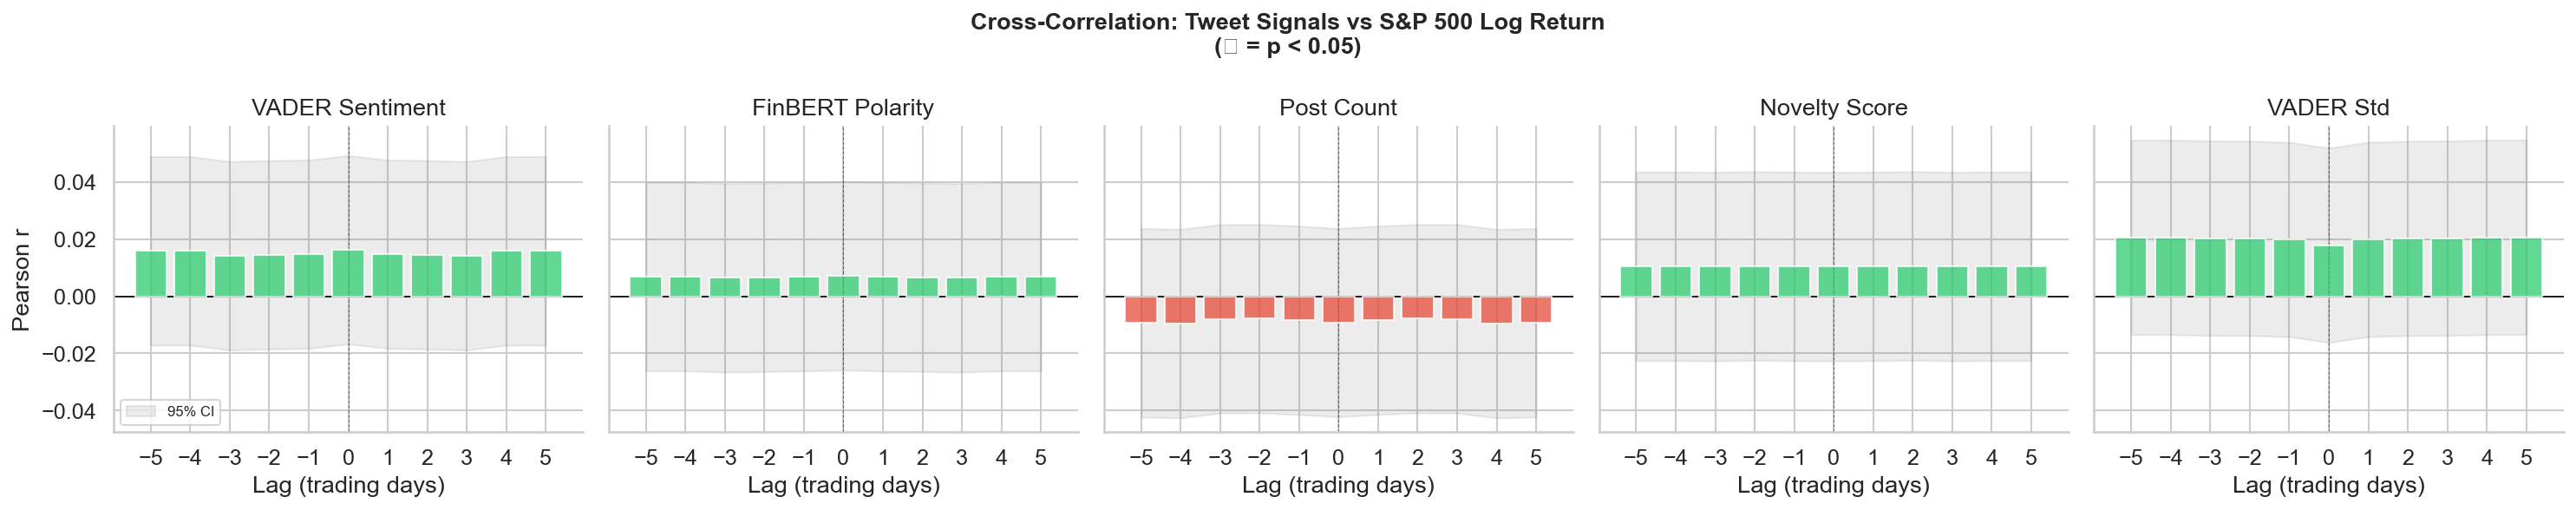


── Cross-correlation at lag +1 ──
  VADER Sentiment         r=+0.0147  p=0.3815
  FinBERT Polarity        r=+0.0068  p=0.6856
  Post Count              r=-0.0084  p=0.6163
  Novelty Score           r=+0.0105  p=0.5356
  VADER Std               r=+0.0199  p=0.2522


In [13]:
def cross_correlation_with_ci(x, y, lags, alpha=0.05):
    records = []
    for lag in lags:
        if lag >= 0:
            x_s = x.iloc[:len(x)-lag] if lag > 0 else x
            y_s = y.iloc[lag:] if lag > 0 else y
        else:
            x_s = x.iloc[-lag:]
            y_s = y.iloc[:len(y)+lag]
        combined = pd.concat([x_s.rename("x"), y_s.rename("y")], axis=1).dropna()
        n = len(combined)
        if n < 10:
            continue
        r, p = stats.pearsonr(combined["x"], combined["y"])
        z = np.arctanh(r)
        se = 1 / np.sqrt(n - 3)
        z_crit = stats.norm.ppf(1 - alpha / 2)
        records.append({"lag": lag, "r": r, "p_value": p,
                        "ci_low": np.tanh(z - z_crit * se),
                        "ci_high": np.tanh(z + z_crit * se), "n": n})
    return pd.DataFrame(records)

LAGS = range(-5, 6)
signals = {
    "VADER Sentiment":  "vader_mean",
    "FinBERT Polarity": "finbert_mean",
    "Post Count":       "post_count",
    "Novelty Score":    "novelty_score",
    "VADER Std":        "vader_std",
}
returns = fm.set_index("date_only")["log_return"]
cc_results = {}
for label, col in signals.items():
    if col in fm.columns:
        cc_results[label] = cross_correlation_with_ci(
            fm.set_index("date_only")[col], returns, LAGS)

# Plot
n = len(cc_results)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
for ax, (label, df) in zip(axes, cc_results.items()):
    bar_colors = [C_POSITIVE if r > 0 else C_NEGATIVE for r in df["r"]]
    ax.bar(df["lag"], df["r"], color=bar_colors, alpha=0.75, zorder=3)
    ax.fill_between(df["lag"], df["ci_low"], df["ci_high"],
                    alpha=0.15, color="grey", label="95% CI")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5)
    sig = df[df["p_value"] < 0.05]
    if len(sig):
        ax.scatter(sig["lag"], sig["r"] + np.sign(sig["r"]) * 0.003,
                   marker="*", color=C_HIGHLIGHT, s=80, zorder=5)
    ax.set(title=label, xlabel="Lag (trading days)", xticks=list(LAGS))
    if ax == axes[0]:
        ax.set_ylabel("Pearson r")
        ax.legend(fontsize=8)

plt.suptitle("Cross-Correlation: Tweet Signals vs S&P 500 Log Return\n(★ = p < 0.05)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
savefig("10_cross_correlation")
plt.show()

print("\n── Cross-correlation at lag +1 ──")
for label, df in cc_results.items():
    row = df[df["lag"] == 1]
    if len(row):
        r = row.iloc[0]
        sig = "*" if r["p_value"] < 0.05 else ""
        print(f"  {label:<22}  r={r['r']:+.4f}  p={r['p_value']:.4f}{sig}")


---
## 13 — Significance Testing with Newey-West HAC Standard Errors

Financial time series are autocorrelated, making standard p-values anti-conservative.
We use Newey-West (HAC) standard errors and apply a Bonferroni correction across
the five signals tested.


  Saved: 11_newey_west.png


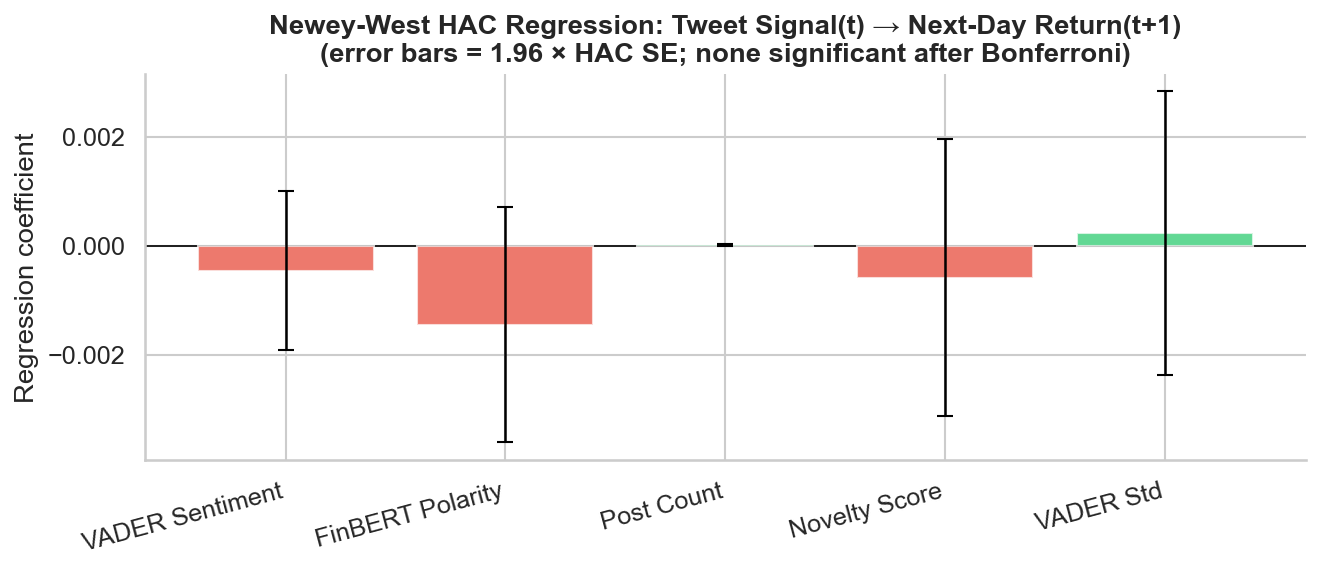


── Newey-West results ──
                    coef  hac_se  t_stat  p_value  p_bonferroni  significant
feature                                                                     
VADER Sentiment  -0.0005  0.0007 -0.6130   0.5399        1.0000        False
FinBERT Polarity -0.0014  0.0011 -1.3188   0.1873        0.9366        False
Post Count        0.0000  0.0000  1.1784   0.2387        1.0000        False
Novelty Score    -0.0006  0.0013 -0.4518   0.6514        1.0000        False
VADER Std         0.0002  0.0013  0.1769   0.8596        1.0000        False


In [14]:
def newey_west_test(x, y, n_lags=5):
    combined = pd.concat([x.rename("x"), y.rename("y")], axis=1).dropna()
    X = sm.add_constant(combined["x"])
    model = sm.OLS(combined["y"], X).fit()
    hac_cov = cov_hac(model, nlags=n_lags)
    hac_se  = np.sqrt(np.diag(hac_cov))
    t_stat  = model.params["x"] / hac_se[1]
    p_value = 2 * stats.t.sf(np.abs(t_stat), df=model.df_resid)
    return {"coef": model.params["x"], "hac_se": hac_se[1],
            "t_stat": t_stat, "p_value": p_value, "n": len(combined)}

target = fm.set_index("date_only")["next_log_return"]
nw_records = []
for label, col in signals.items():
    if col not in fm.columns:
        continue
    signal = fm.set_index("date_only")[col].shift(1)
    result = newey_west_test(signal, target)
    result["feature"] = label
    nw_records.append(result)

nw_df = pd.DataFrame(nw_records).set_index("feature")
n_tests = len(nw_df)
nw_df["p_bonferroni"] = (nw_df["p_value"] * n_tests).clip(upper=1.0)
nw_df["significant"]  = nw_df["p_bonferroni"] < 0.05

fig, ax = plt.subplots(figsize=(9, 4))
x_pos  = np.arange(len(nw_df))
coefs  = nw_df["coef"].values
ses    = nw_df["hac_se"].values
colors_nw = [C_POSITIVE if c > 0 else C_NEGATIVE for c in coefs]
ax.bar(x_pos, coefs, color=colors_nw, alpha=0.75, zorder=3)
ax.errorbar(x_pos, coefs, yerr=1.96 * ses,
            fmt="none", color="black", capsize=4, linewidth=1.2, zorder=4)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(nw_df.index, rotation=15, ha="right")
ax.set_ylabel("Regression coefficient")
ax.set_title("Newey-West HAC Regression: Tweet Signal(t) → Next-Day Return(t+1)\n"
             "(error bars = 1.96 × HAC SE; none significant after Bonferroni)",
             fontweight="bold")
plt.tight_layout()
savefig("11_newey_west")
plt.show()

print("\n── Newey-West results ──")
print(nw_df[["coef","hac_se","t_stat","p_value","p_bonferroni","significant"]].round(4).to_string())


---
## 14 — Topic-Level Regression

For each BERTopic theme flag, we estimate:
r_{t+1} = α + β·topic_t + γ·r_t + ε_t

β captures the average next-day return difference on topic days vs non-topic days,
controlling for the autoregressive return component.


Found 15 topic flags
  Saved: 12_topic_regression.png


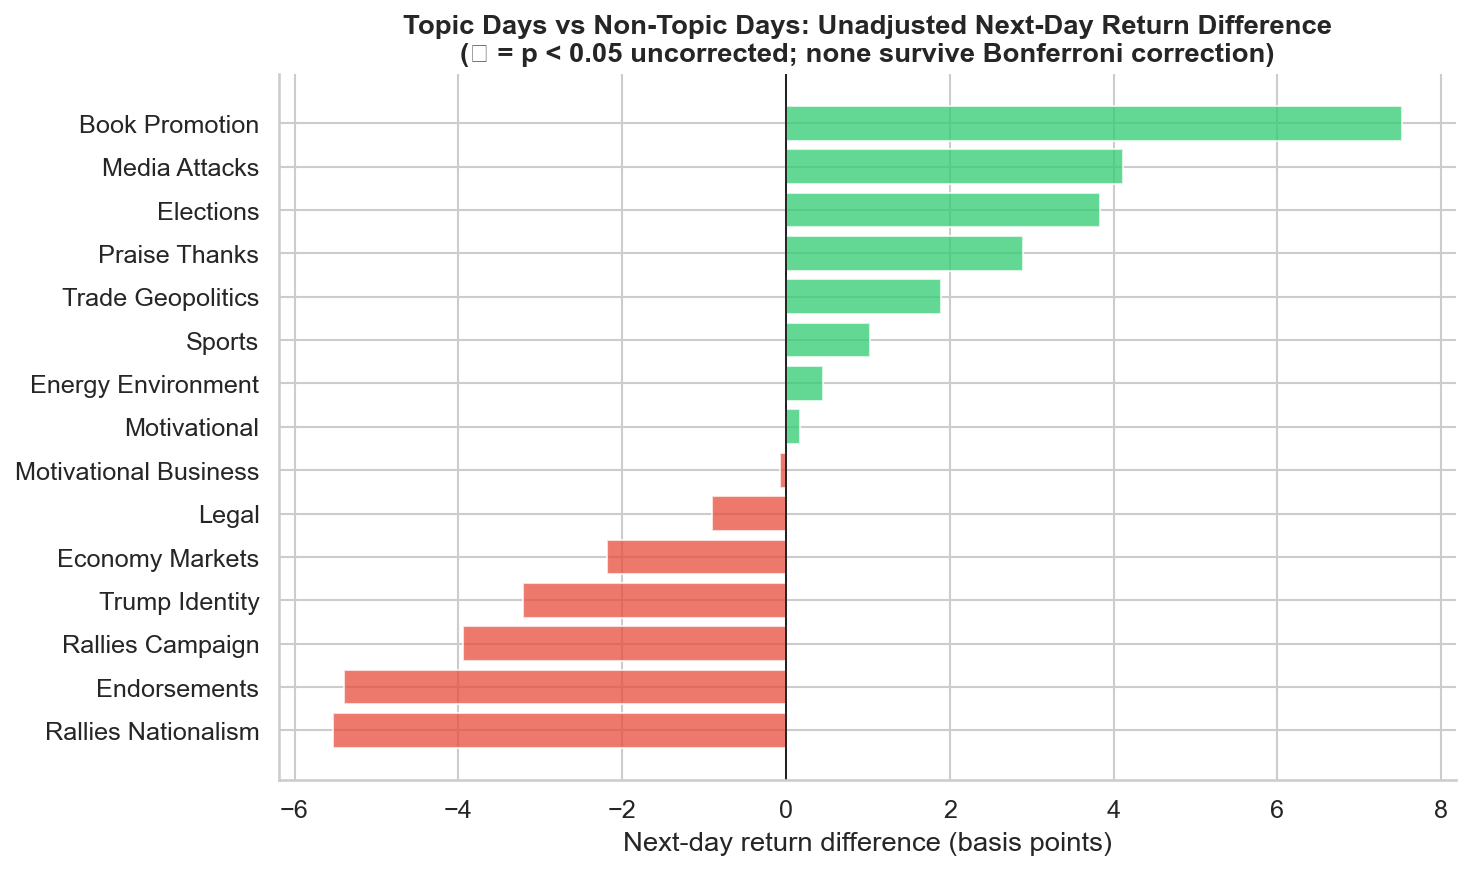

In [15]:
topic_cols = [c for c in fm.columns
              if c.startswith("topic_") and not c.endswith("_premarket")]
print(f"Found {len(topic_cols)} topic flags")

topic_records = []
for col in topic_cols:
    df_reg = fm[["date_only", col, "log_return", "next_log_return"]].dropna().copy()
    df_reg = df_reg.sort_values("date_only")
    X = sm.add_constant(df_reg[[col, "log_return"]])
    model = sm.OLS(df_reg["next_log_return"], X).fit()
    hac_cov = cov_hac(model, nlags=5)
    hac_se  = np.sqrt(np.diag(hac_cov))
    col_idx = X.columns.tolist().index(col)
    beta    = model.params[col]
    t_stat  = beta / hac_se[col_idx]
    p_val   = 2 * stats.t.sf(np.abs(t_stat), df=model.df_resid)
    mean_t  = df_reg.loc[df_reg[col]==1, "next_log_return"].mean()
    mean_nt = df_reg.loc[df_reg[col]==0, "next_log_return"].mean()
    topic_records.append({
        "topic":         col.replace("topic_","").replace("_"," ").title(),
        "n_topic_days":  int(df_reg[col].sum()),
        "raw_diff_bps":  (mean_t - mean_nt) * 10_000,
        "beta_adj":      beta, "t_stat": t_stat, "p_value": p_val,
    })

topic_df = pd.DataFrame(topic_records).sort_values("raw_diff_bps")
topic_df["p_bonferroni"] = (topic_df["p_value"] * len(topic_df)).clip(upper=1.0)
topic_df["significant"]  = topic_df["p_bonferroni"] < 0.05

fig, ax = plt.subplots(figsize=(10, 6))
colors_topic = [C_POSITIVE if d > 0 else C_NEGATIVE for d in topic_df["raw_diff_bps"]]
ax.barh(topic_df["topic"], topic_df["raw_diff_bps"], color=colors_topic, alpha=0.75)
ax.axvline(0, color="black", linewidth=0.8)

for i, (_, row) in enumerate(topic_df.iterrows()):
    if row["p_value"] < 0.05:
        x = row["raw_diff_bps"]
        ax.text(x + (0.5 if x > 0 else -0.5), i, "★",
                va="center", fontsize=10, color=C_HIGHLIGHT)

ax.set_xlabel("Next-day return difference (basis points)")
ax.set_title("Topic Days vs Non-Topic Days: Unadjusted Next-Day Return Difference\n"
             "(★ = p < 0.05 uncorrected; none survive Bonferroni correction)",
             fontweight="bold")
plt.tight_layout()
savefig("12_topic_regression")
plt.show()


---
## 15 — Event Study: Cumulative Abnormal Returns

We identify days in the top and bottom 5% of the VADER distribution as extreme
posting events and compute CARs over a [−3, +3] window around each event.
Market shock days (|return| > 2σ) are excluded to avoid confounding.

**Key finding:** Strongly positive posting days are preceded by market gains
(significant pre-event CAR = +0.33%), but show no significant post-event CAR —
consistent with reactive rather than market-moving posting behaviour.


  Saved: 13_event_study.png


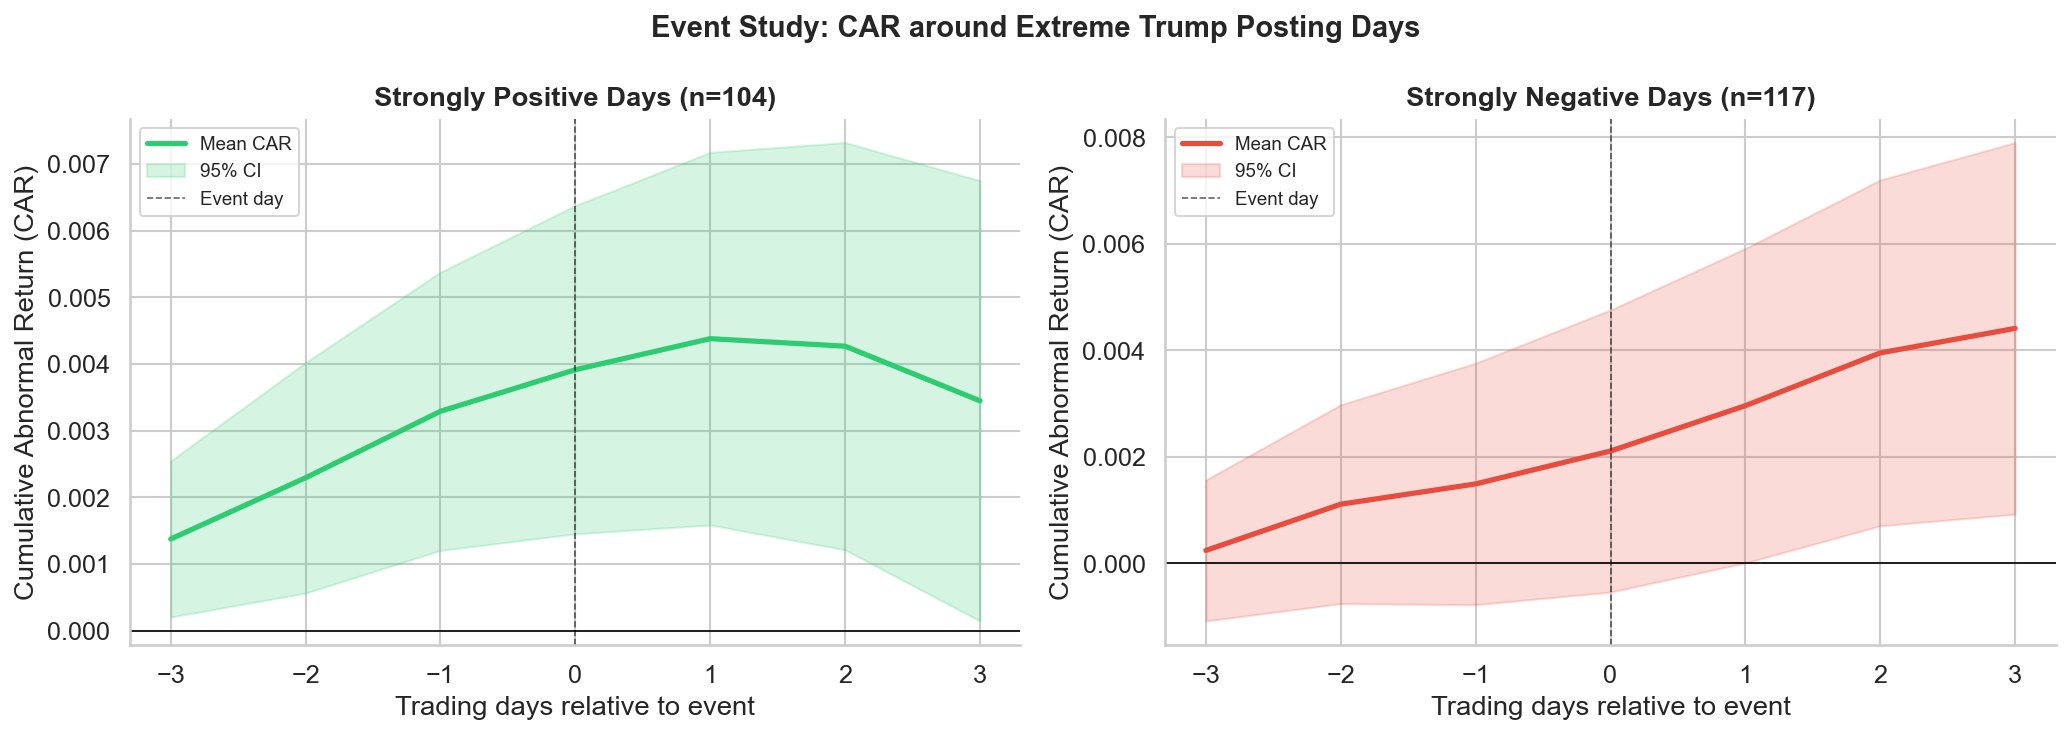


  Positive portfolio (n=104):
    [-3,-1] pre-event      CAR=+0.0033  t=+3.19  p=0.0019*
    [0,+1] short-term      CAR=+0.0011  t=+1.13  p=0.2607
    [0,+3] full window     CAR=+0.0002  t=+0.12  p=0.9083

  Negative portfolio (n=117):
    [-3,-1] pre-event      CAR=+0.0015  t=+1.30  p=0.1975
    [0,+1] short-term      CAR=+0.0015  t=+1.70  p=0.0917
    [0,+3] full window     CAR=+0.0029  t=+2.36  p=0.0198*


In [16]:
fm_es = fm[["date_only","log_return","vader_mean"]].dropna().copy()
fm_es = fm_es.sort_values("date_only").reset_index(drop=True)

p5  = fm_es["vader_mean"].quantile(0.05)
p95 = fm_es["vader_mean"].quantile(0.95)
return_std  = fm_es["log_return"].std()
shock_dates = set(fm_es.loc[fm_es["log_return"].abs() > 2*return_std, "date_only"])

def near_shock(date, window=5):
    idx = fm_es.index[fm_es["date_only"] == date]
    if len(idx) == 0: return False
    i = idx[0]
    neighbors = fm_es.iloc[max(0,i-window):i+window+1]["date_only"]
    return any(d in shock_dates for d in neighbors)

pos_events = fm_es[(fm_es["vader_mean"] >= p95) &
                   (~fm_es["date_only"].apply(near_shock))]["date_only"].values
neg_events = fm_es[(fm_es["vader_mean"] <= p5) &
                   (~fm_es["date_only"].apply(near_shock))]["date_only"].values

LAGS_ES = list(range(-3, 4))
EST_WIN, PRE_GAP = 60, 10

def compute_cars(event_dates):
    all_ars = []
    for ev in event_dates:
        idx = fm_es.index[fm_es["date_only"] == ev]
        if len(idx) == 0: continue
        i = idx[0]
        es, ee = i - PRE_GAP - EST_WIN, i - PRE_GAP
        if es < 0 or i + len(LAGS_ES) > len(fm_es): continue
        mean_ret = fm_es.iloc[es:ee]["log_return"].mean()
        ars = fm_es.iloc[i-3:i+4]["log_return"].values - mean_ret
        if len(ars) == len(LAGS_ES): all_ars.append(ars)
    return np.array(all_ars)

pos_ars = compute_cars(pos_events)
neg_ars = compute_cars(neg_events)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ars, title, color in zip(
    axes,
    [pos_ars, neg_ars],
    [f"Strongly Positive Days (n={len(pos_ars)})",
     f"Strongly Negative Days (n={len(neg_ars)})"],
    [C_POSITIVE, C_NEGATIVE]
):
    mean_car = np.cumsum(ars.mean(axis=0))
    se_car   = np.sqrt(np.cumsum((ars.std(axis=0) / np.sqrt(len(ars)))**2))
    ax.plot(LAGS_ES, mean_car, color=color, linewidth=2.5, label="Mean CAR")
    ax.fill_between(LAGS_ES, mean_car - 1.96*se_car, mean_car + 1.96*se_car,
                    alpha=0.2, color=color, label="95% CI")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6,
               label="Event day")
    ax.set_xticks(LAGS_ES)
    ax.set_xlabel("Trading days relative to event")
    ax.set_ylabel("Cumulative Abnormal Return (CAR)")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("Event Study: CAR around Extreme Trump Posting Days",
             fontsize=14, fontweight="bold")
plt.tight_layout()
savefig("13_event_study")
plt.show()

# Print CAR significance
def car_sig(ars, i1, i2):
    cars = ars[:, i1:i2+1].sum(axis=1)
    t = cars.mean() / (cars.std(ddof=1) / np.sqrt(len(cars)))
    p = 2 * stats.t.sf(np.abs(t), df=len(cars)-1)
    return cars.mean(), t, p

z = LAGS_ES.index(0)
for name, ars in [("Positive", pos_ars), ("Negative", neg_ars)]:
    print(f"\n  {name} portfolio (n={len(ars)}):")
    for wname, (i1,i2) in [("[-3,-1] pre-event",(0,z-1)),
                             ("[0,+1] short-term",(z,z+1)),
                             ("[0,+3] full window",(z,len(LAGS_ES)-1))]:
        car, t, p = car_sig(ars, i1, i2)
        sig = "*" if p < 0.05 else ""
        print(f"    {wname:<22} CAR={car:+.4f}  t={t:+.2f}  p={p:.4f}{sig}")


  Saved: 13b_event_study_finbert.png


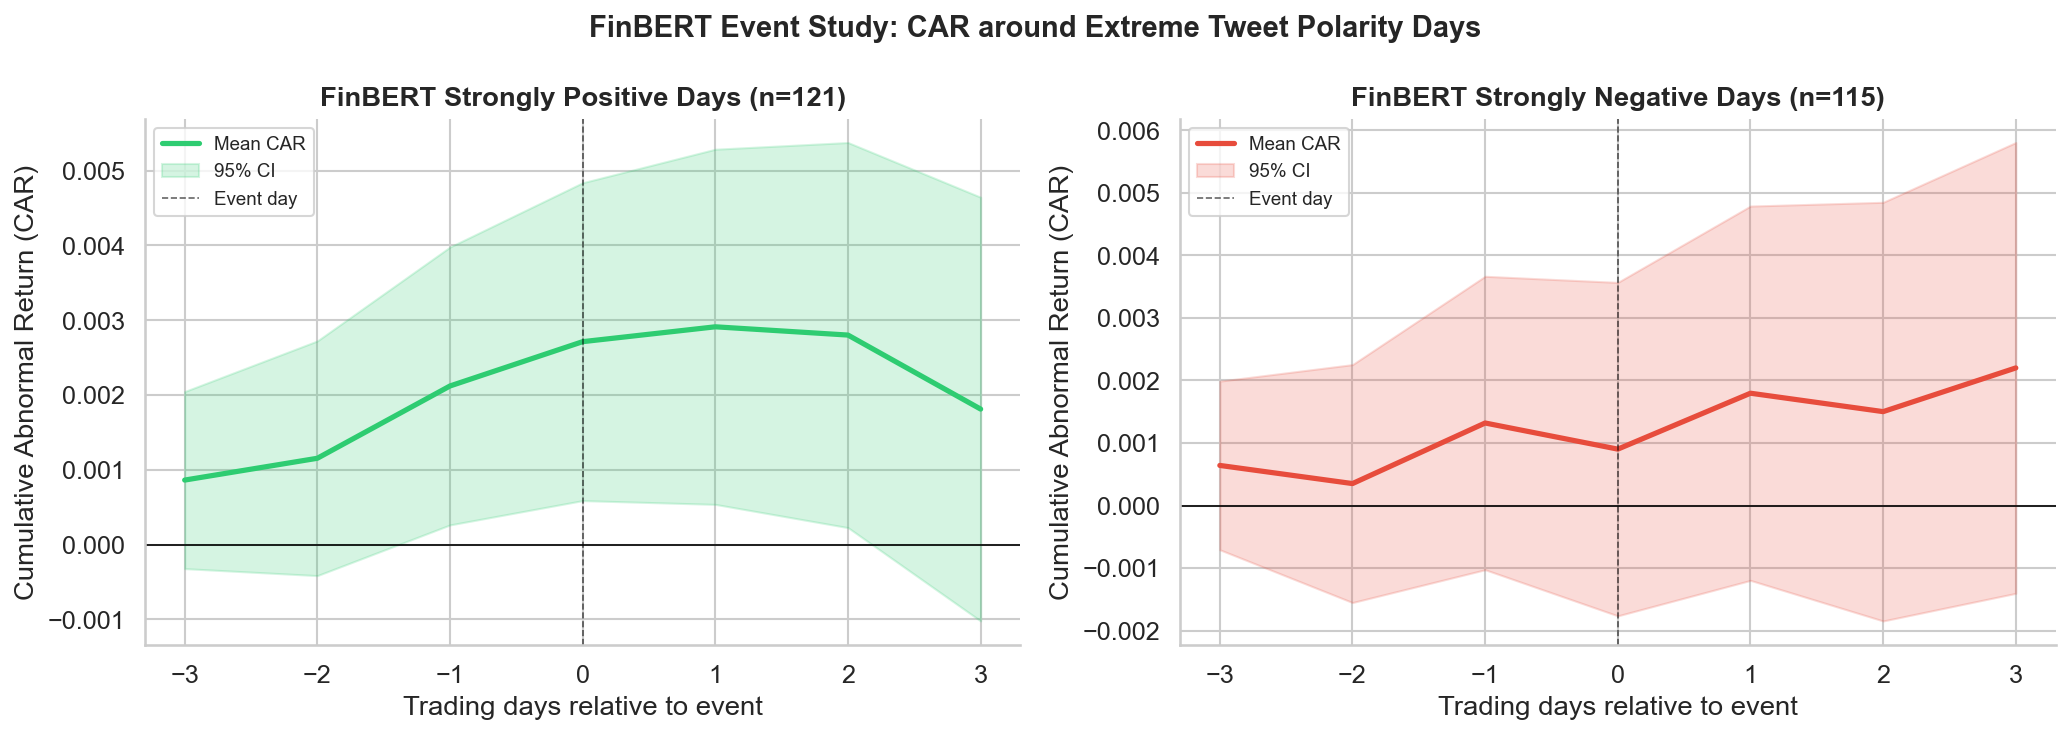


  FinBERT Positive portfolio (n=121):
    [-3,-1] pre-event      CAR=+0.0021  t=+2.14  p=0.0347*
    [0,+1] short-term      CAR=+0.0008  t=+1.09  p=0.2801
    [0,+3] full window     CAR=-0.0003  t=-0.27  p=0.7868

  FinBERT Negative portfolio (n=115):
    [-3,-1] pre-event      CAR=+0.0013  t=+1.17  p=0.2434
    [0,+1] short-term      CAR=+0.0005  t=+0.50  p=0.6163
    [0,+3] full window     CAR=+0.0009  t=+0.62  p=0.5348


In [22]:
if "finbert_mean" in fm.columns:
    fm_es_fb = fm[["date_only", "log_return", "finbert_mean"]].dropna().copy()
    fm_es_fb = fm_es_fb.sort_values("date_only").reset_index(drop=True)

    p5_fb  = fm_es_fb["finbert_mean"].quantile(0.05)
    p95_fb = fm_es_fb["finbert_mean"].quantile(0.95)
    return_std_fb  = fm_es_fb["log_return"].std()
    shock_dates_fb = set(fm_es_fb.loc[fm_es_fb["log_return"].abs() > 2*return_std_fb, "date_only"])

    def near_shock_fb(date, window=5):
        idx = fm_es_fb.index[fm_es_fb["date_only"] == date]
        if len(idx) == 0:
            return False
        i = idx[0]
        neighbors = fm_es_fb.iloc[max(0, i-window):i+window+1]["date_only"]
        return any(d in shock_dates_fb for d in neighbors)

    pos_events_fb = fm_es_fb[(fm_es_fb["finbert_mean"] >= p95_fb) &
                             (~fm_es_fb["date_only"].apply(near_shock_fb))]["date_only"].values
    neg_events_fb = fm_es_fb[(fm_es_fb["finbert_mean"] <= p5_fb) &
                             (~fm_es_fb["date_only"].apply(near_shock_fb))]["date_only"].values

    def compute_cars_fb(event_dates):
        all_ars = []
        for ev in event_dates:
            idx = fm_es_fb.index[fm_es_fb["date_only"] == ev]
            if len(idx) == 0:
                continue
            i = idx[0]
            es, ee = i - PRE_GAP - EST_WIN, i - PRE_GAP
            if es < 0 or i + len(LAGS_ES) > len(fm_es_fb):
                continue
            mean_ret = fm_es_fb.iloc[es:ee]["log_return"].mean()
            ars = fm_es_fb.iloc[i-3:i+4]["log_return"].values - mean_ret
            if len(ars) == len(LAGS_ES):
                all_ars.append(ars)
        return np.array(all_ars)

    pos_ars_fb = compute_cars_fb(pos_events_fb)
    neg_ars_fb = compute_cars_fb(neg_events_fb)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, ars, title, color in zip(
        axes,
        [pos_ars_fb, neg_ars_fb],
        [f"FinBERT Strongly Positive Days (n={len(pos_ars_fb)})",
         f"FinBERT Strongly Negative Days (n={len(neg_ars_fb)})"],
        [C_POSITIVE, C_NEGATIVE]
    ):
        if len(ars) == 0:
            ax.text(0.5, 0.5, "No valid event windows", ha="center", va="center", fontsize=12)
            ax.set_title(title, fontweight="bold")
            ax.set_xlabel("Trading days relative to event")
            ax.set_ylabel("Cumulative Abnormal Return (CAR)")
            continue

        mean_car = np.cumsum(ars.mean(axis=0))
        se_car   = np.sqrt(np.cumsum((ars.std(axis=0) / np.sqrt(len(ars)))**2))
        ax.plot(LAGS_ES, mean_car, color=color, linewidth=2.5, label="Mean CAR")
        ax.fill_between(LAGS_ES, mean_car - 1.96*se_car, mean_car + 1.96*se_car,
                        alpha=0.2, color=color, label="95% CI")
        ax.axhline(0, color="black", linewidth=0.8)
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6,
                   label="Event day")
        ax.set_xticks(LAGS_ES)
        ax.set_xlabel("Trading days relative to event")
        ax.set_ylabel("Cumulative Abnormal Return (CAR)")
        ax.set_title(title, fontweight="bold")
        ax.legend(fontsize=9)

    plt.suptitle("FinBERT Event Study: CAR around Extreme Tweet Polarity Days",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    savefig("13b_event_study_finbert")
    plt.show()

    def car_sig(ars, i1, i2):
        cars = ars[:, i1:i2+1].sum(axis=1)
        t = cars.mean() / (cars.std(ddof=1) / np.sqrt(len(cars)))
        p = 2 * stats.t.sf(np.abs(t), df=len(cars)-1)
        return cars.mean(), t, p

    z = LAGS_ES.index(0)
    for name, ars in [("Positive", pos_ars_fb), ("Negative", neg_ars_fb)]:
        if len(ars) == 0:
            print(f"\n  FinBERT {name} portfolio: no valid event windows")
            continue
        print(f"\n  FinBERT {name} portfolio (n={len(ars)}):")
        for wname, (i1, i2) in [("[-3,-1] pre-event",(0,z-1)),
                                 ("[0,+1] short-term",(z,z+1)),
                                 ("[0,+3] full window",(z,len(LAGS_ES)-1))]:
            car, t, p = car_sig(ars, i1, i2)
            sig = "*" if p < 0.05 else ""
            print(f"    {wname:<22} CAR={car:+.4f}  t={t:+.2f}  p={p:.4f}{sig}")
else:
    print("FinBERT event study skipped because 'finbert_mean' is not available in fm.")


---
## 16 — Platform Subgroup Analysis

We repeat the lag-1 correlation tests separately for the Twitter period (pre-Jan 2021)
and Truth Social period (post-Jan 2021) to check whether the platform switch
changed the market relationship.


Twitter period    : 2,600 days
Truth Social period: 926 days
  Saved: 14_platform_comparison.png


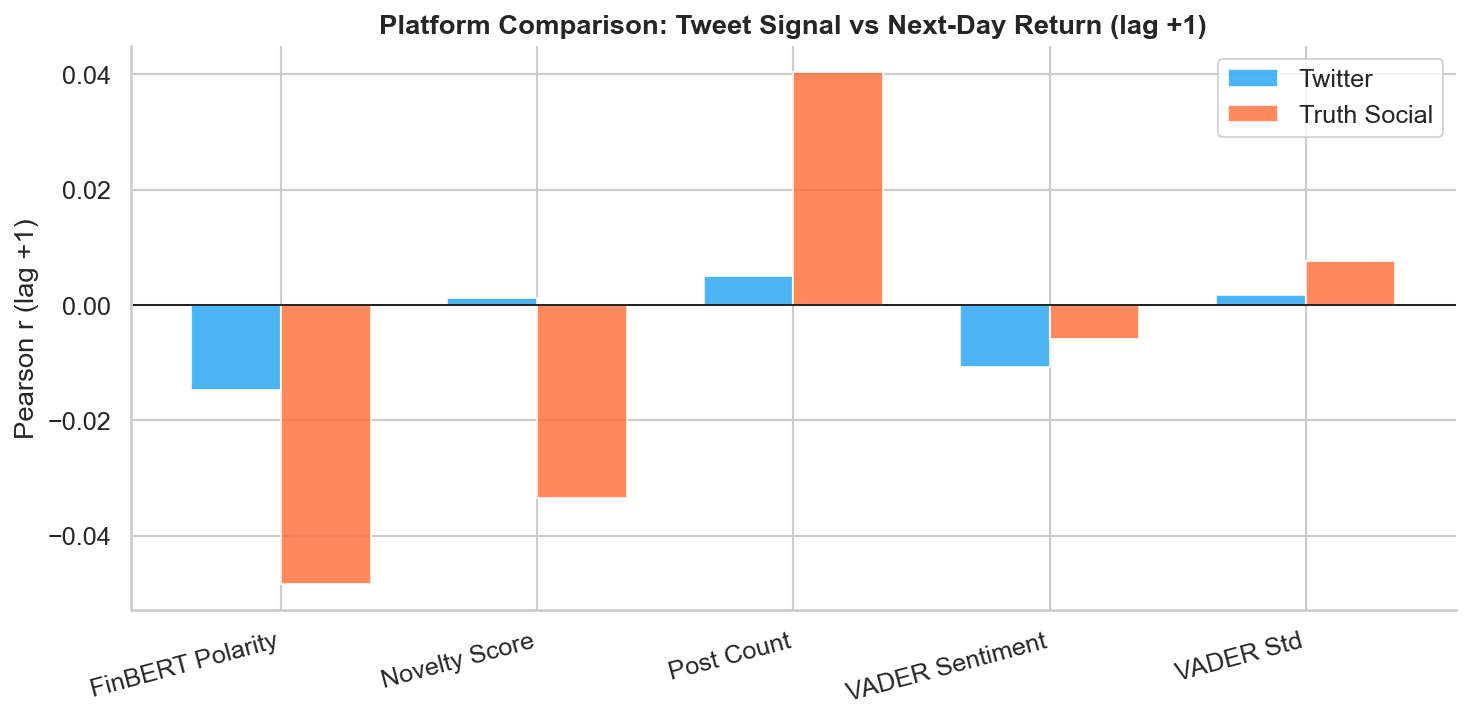


Pearson r by platform:
platform          Truth Social  Twitter
feature                                
FinBERT Polarity       -0.0483  -0.0148
Novelty Score          -0.0335   0.0013
Post Count              0.0404   0.0050
VADER Sentiment        -0.0059  -0.0108
VADER Std               0.0077   0.0017


In [17]:
SWITCH = pd.Timestamp("2021-01-08")
fm_tw   = fm[fm["date_only"] <  SWITCH].copy()
fm_ts   = fm[fm["date_only"] >= SWITCH].copy()

print(f"Twitter period    : {len(fm_tw):,} days")
print(f"Truth Social period: {len(fm_ts):,} days")

plat_records = []
for plat_name, subset in [("Twitter", fm_tw), ("Truth Social", fm_ts)]:
    for label, col in signals.items():
        if col not in subset.columns: continue
        sig = subset.set_index("date_only")[col].shift(1)
        tgt = subset.set_index("date_only")["next_log_return"]
        combined = pd.concat([sig, tgt], axis=1).dropna()
        if len(combined) < 20: continue
        r, p = stats.pearsonr(combined.iloc[:,0], combined.iloc[:,1])
        plat_records.append({"platform": plat_name, "feature": label,
                              "r": r, "p_value": p, "n": len(combined)})

plat_df = pd.DataFrame(plat_records)
pivot_r = plat_df.pivot(index="feature", columns="platform", values="r")

fig, ax = plt.subplots(figsize=(10, 5))
x    = np.arange(len(pivot_r))
w    = 0.35
for i, (plat, col) in enumerate([("Twitter", C_TWITTER), ("Truth Social", C_TRUTH)]):
    if plat not in pivot_r.columns: continue
    vals = pivot_r[plat].values
    ax.bar(x + i*w - w/2, vals, w, label=plat, color=col, alpha=0.8)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(pivot_r.index, rotation=15, ha="right")
ax.set_ylabel("Pearson r (lag +1)")
ax.set_title("Platform Comparison: Tweet Signal vs Next-Day Return (lag +1)",
             fontweight="bold")
ax.legend()
plt.tight_layout()
savefig("14_platform_comparison")
plt.show()

print("\nPearson r by platform:")
print(pivot_r.round(4))


---
## 17 — Save Results

In [18]:
# Save key tables for the report
nw_df.to_csv(ANALYSIS_DIR / "newey_west_results.csv")
topic_df.to_csv(ANALYSIS_DIR / "topic_regression_results.csv", index=False)
plat_df.to_csv(ANALYSIS_DIR / "platform_comparison.csv", index=False)

print("Saved to:", ANALYSIS_DIR)
for f in sorted(ANALYSIS_DIR.iterdir()):
    print(f"  {f.name}")


Saved to: c:\Dev\nlp-final-project\5_analysis\results
  newey_west_results.csv
  platform_comparison.csv
  topic_regression_results.csv
